# Chapter 4 — Results Production Notebook

This notebook orchestrates all figures and tables for the restructured Chapter 4.  
Each section mirrors the thesis structure. Run cells individually to iterate on specific figures.

**Structure:**
- §4.1 Corpus Overview and Register Distinctiveness
- §4.2 Lexical Patterns Across Registers (keyness, exclusivity, co-occurrence)
- §4.3 Thematic Structure: STM
- §4.4 Interpretive Synthesis: H1a–H1c with Close Reading

**Prerequisites:** All pipeline scripts (00–03b) must have been run. Database `scraping_2.db` must be populated.

In [2]:
# ── Imports and Setup ──────────────────────────────────────────────────────
import sqlite3
import json
import math
import textwrap
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

try:
    import seaborn as sns
    sns.set_style('whitegrid')
except ImportError:
    pass

try:
    import networkx as nx
    _HAS_NX = True
except ImportError:
    _HAS_NX = False
    print('WARNING: networkx not installed — topic network figure will be skipped')

%matplotlib inline
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'serif'

In [3]:
# ── Configuration ──────────────────────────────────────────────────────────

DB_PATH = '../data/scraping_2.db'        # adjust if needed
FIG_DIR = Path('../output/chapter4/')     # all Chapter 4 figures saved here
FIG_DIR.mkdir(parents=True, exist_ok=True)

DPI_PUB = 300
DPI_EXP = 150
FIG_FORMAT = 'pdf'   # 'pdf' for vector (thesis), 'png' for quick preview

# ── Colour Palette (consistent across all figures) ─────────────────────────
C_CLIENT  = '#1B4F8A'   # deep blue  — client (B2B)
C_WORKER  = '#C0392B'   # deep red   — worker (B2W)
C_SHARED  = '#6C757D'   # grey       — shared / neutral
C_H1C     = '#E67E22'   # orange     — H1c (strategic hypervisibility)
C_GRID    = '#DEE2E6'
C_TEXT    = '#1A1A2E'

PAL_HYP = {
    'H1a': C_WORKER,
    'H1b': C_CLIENT,
    'H1c': C_H1C,
    None:  C_SHARED,
}

# ── Database connection ────────────────────────────────────────────────────
conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row

# Quick check: which tables exist?
tables = {r[0] for r in conn.execute(
    "SELECT name FROM sqlite_master WHERE type IN ('table','view')"
).fetchall()}
print('Available tables/views:', sorted(tables))


# ── Co-occurrence boilerplate / artefact filter ────────────────────────────
# The simplest possible defence against boilerplate-driven PMI spikes.
# Any collocate in this set is excluded *post-query* from co-occurrence
# profiles. Add terms here as they surface in diagnostics.
#
#   cc0         : appears only in the 11 near-duplicate HITL dataset-release
#                 pages ("dedicate public domain human cc0 license"). Pure
#                 boilerplate; not a substantive client-side discourse.
#   fellowship  : HITL footer artefact, same cluster of pages.
#   rat         : lemmatiser truncation of "rate"/"rating". Preprocessing
#                 artefact, not a real collocate.
#   introduc    : lemmatiser truncation of "introduce".
#
# If a term is genuinely interesting across domains, do not add it here.
COOC_BLOCKLIST = {
    'cc0', 'fellowship', 'rat', 'introduc',
}

# Minimum number of distinct domains a (focus, collocate) pair must appear
# across before we plot it. This is the structural version of the filter:
# a real cross-platform pattern should not rely on one domain's boilerplate.
# Set to 1 to disable the structural filter (blocklist alone will then carry
# all the weight); set to 3 for a stricter cross-platform criterion.
COOC_MIN_DOMAINS = 3


Available tables/views: ['_corpus_view_backup', 'aggregate_distance', 'cooccurrence_results', 'corpus_view', 'distinctiveness_matrix', 'document_topics', 'domain_quality', 'excluded_pages', 'excluded_terms', 'keyness_results', 'lda_diagnostics', 'links', 'page_audience_override', 'pages', 'pages_embedding', 'pages_tfidf', 'platform_term_counts', 'platforms', 'sqlite_sequence', 'step2_sample', 'step2_sample_structured', 'stm_content', 'stm_prevalence', 'stm_theta', 'stm_topic_profile', 'stm_topic_terms', 'term_exclusivity', 'topic_audience_profile', 'topic_terms', 'websites']


In [4]:
# ── Helper functions ───────────────────────────────────────────────────────

def save_fig(fig, name, fmt=FIG_FORMAT, dpi=DPI_PUB):
    """Save figure to FIG_DIR with consistent settings."""
    path = FIG_DIR / f'{name}.{fmt}'
    fig.savefig(str(path), dpi=dpi, bbox_inches='tight', facecolor='white')
    print(f'  Saved: {path}')

def apply_style(ax):
    """Apply consistent thesis style to an axis."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(C_GRID)
    ax.spines['bottom'].set_color(C_GRID)
    ax.tick_params(colors=C_TEXT, labelsize=9)
    ax.set_axisbelow(True)

def to_latex_table(df, caption, label, note='', fmt_cols=None):
    """Convert a DataFrame to a thesis-ready LaTeX tabular string."""
    lines = []
    lines.append(r'\begin{table}[ht]')
    lines.append(r'  \centering')
    lines.append(f'  \\caption{{{caption}}}')
    lines.append(f'  \\label{{{label}}}')
    lines.append(r'  \small')
    col_fmt = 'l' + 'r' * (len(df.columns) - 1)
    lines.append(f'  \\begin{{tabular}}{{{col_fmt}}}')
    lines.append(r'    \toprule')
    headers = ' & '.join(str(c) for c in df.columns) + r' \\'
    lines.append(f'    {headers}')
    lines.append(r'    \midrule')
    for _, row in df.iterrows():
        vals = ' & '.join(str(v) for v in row.values) + r' \\'
        lines.append(f'    {vals}')
    lines.append(r'    \bottomrule')
    lines.append(r'  \end{tabular}')
    if note:
        lines.append(r'  \begin{tablenotes}')
        lines.append(r'    \small')
        lines.append(f'    \\item \\textit{{Note.}} {note}')
        lines.append(r'  \end{tablenotes}')
    lines.append(r'\end{table}')
    return '\n'.join(lines)

---
## §4.1 — Corpus Overview and Register Distinctiveness

In [5]:
# ── §4.1.1: Corpus composition stats ──────────────────────────────────────
# These numbers go directly into the text of §4.1

stats = pd.read_sql("""
    SELECT
        audience,
        COUNT(DISTINCT domain) AS n_platforms,
        COUNT(*)               AS n_pages,
        SUM(token_count)       AS total_tokens
    FROM corpus_view
    WHERE page_id NOT IN (SELECT page_id FROM excluded_pages)
      AND audience != 'both'
    GROUP BY audience
""", conn)

total_pages = stats['n_pages'].sum()
stats['pct'] = (stats['n_pages'] / total_pages * 100).round(1)

print('=== Corpus Composition ===')
print(stats.to_string(index=False))
print(f'\nTotal pages (excl. both): {total_pages}')

=== Corpus Composition ===
audience  n_platforms  n_pages  total_tokens  pct
  client           23     6692       4621454 88.8
  worker           14      843        730306 11.2

Total pages (excl. both): 7535


In [8]:
# ── §4.1.2: Lexical diversity (TTR) ───────────────────────────────────────

ttr = pd.read_sql("""
    SELECT
        audience,
        SUM(token_count) AS total_tokens,
        COUNT(*) AS n_pages
    FROM corpus_view
    WHERE page_id NOT IN (SELECT page_id FROM excluded_pages)
      AND audience != 'both'
    GROUP BY audience
""", conn)

# Unique tokens need to be computed from the actual unigram lists
for aud in ['worker', 'client']:
    rows = conn.execute("""
        SELECT unigrams FROM corpus_view
        WHERE audience = ? AND page_id NOT IN (SELECT page_id FROM excluded_pages)
    """, (aud,)).fetchall()
    all_terms = set()
    for r in rows:
        if r[0]:
            tokens = json.loads(r[0]) if isinstance(r[0], str) else r[0]
            if isinstance(tokens, list):
                all_terms.update(tokens)
            elif isinstance(tokens, dict):
                all_terms.update(tokens.keys())
    mask = ttr['audience'] == aud
    ttr.loc[mask, 'unique_tokens'] = len(all_terms)

ttr['ttr'] = ttr['unique_tokens'] / ttr['total_tokens']

print('=== Lexical Diversity ===')
print(ttr.to_string(index=False))

=== Lexical Diversity ===
audience  total_tokens  n_pages  unique_tokens      ttr
  client       4621454     6692        40704.0 0.008808
  worker        730306      843        27486.0 0.037636


In [9]:
# ── §4.1.3: Aggregate JSD and Cosine ──────────────────────────────────────
# These values were computed by 02_step1_analysis.py section E
# and may be stored in the DB or printed to stdout during that run.
# Check if they're in a table:

if 'aggregate_distance' in tables:
    agg = pd.read_sql('SELECT * FROM aggregate_distance', conn)
    print(agg)
elif 'distinctiveness_matrix' in tables:
    # Compute from the pairwise matrix
    print('aggregate_distance table not found.')
    print('Computing from distinctiveness_matrix...')
    # TODO: compute aggregate JSD between all-client vs all-worker vectors
    print('ACTION NEEDED: add aggregate computation here or extract from script logs')
else:
    print('Neither aggregate_distance nor distinctiveness_matrix found in DB.')
    print('Run 02_step1_analysis.py first.')

   id                comparison       jsd  cosine_sim  n_client_tokens  \
0   1  cross_platform_aggregate  0.194251    0.766479          3371522   

   n_worker_tokens           created_at  
0           702135  2026-03-27 12:45:47  


/Users/yannickkayser/Uni/Master/Master_Thesis/DarkSideofAI/venv-plot/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


Domains in distance matrix: ['crowdgen.com', 'defined.ai', 'humansintheloop.org', 'imerit.net', 'joinstellar.ai', 'labelbox.com', 'mindrift.ai', 'mindy-support.com', 'outlier.ai', 'remoter.me', 'scale.com', 'toloka.ai', 'www.abaka.ai', 'www.alignerr.com', 'www.appen.com', 'www.centific.com', 'www.cloudfactory.com', 'www.crowdworks.ai', 'www.dataannotation.tech', 'www.digitaldividedata.com', 'www.lxt.ai', 'www.microworkers.com', 'www.oneforma.com', 'www.remotasks.com', 'www.sama.com', 'www.superannotate.com']
Audience map: {'mindrift.ai': 'worker', 'crowdgen.com': 'worker', 'www.appen.com': 'client', 'scale.com': 'client', 'www.remotasks.com': 'worker', 'www.sama.com': 'client', 'toloka.ai': 'client', 'www.lxt.ai': 'client', 'www.clickworker.com': 'worker', 'www.microworkers.com': 'worker', 'www.oneforma.com': 'worker', 'www.dataannotation.tech': 'worker', 'outlier.ai': 'worker', 'www.mturk.com': 'both', 'www.prolific.com': 'worker', 'surgehq.ai': 'client', 'defined.ai': 'client', 'www.

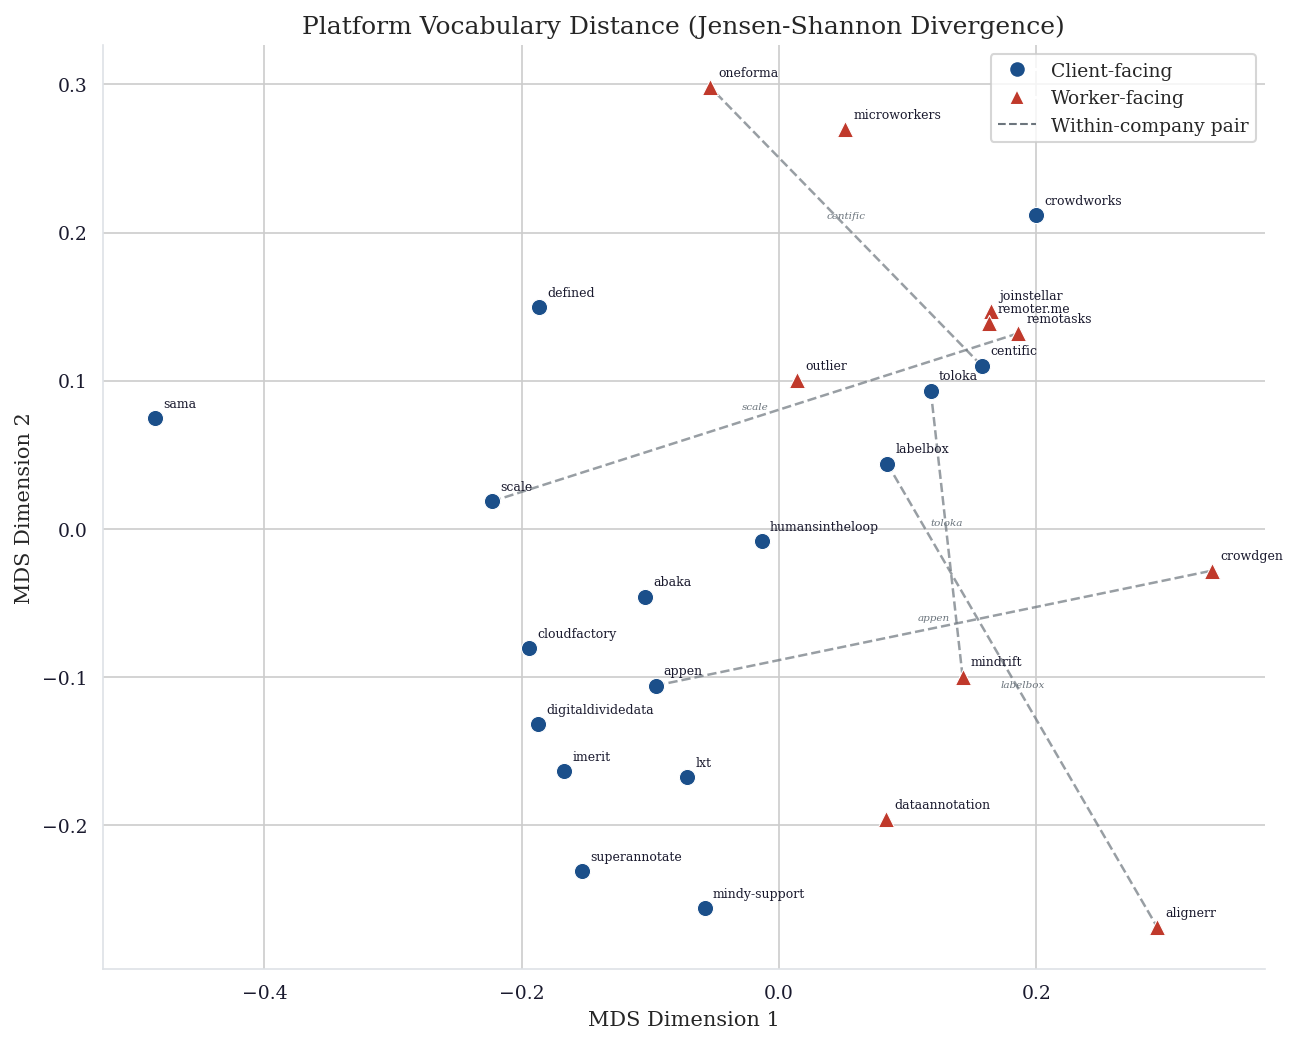


=== Within-company pair JSD distances ===
  www.appen.com ↔ crowdgen.com: JSD = 0.4102
  toloka.ai ↔ mindrift.ai: JSD = 0.2556
  www.centific.com ↔ www.oneforma.com: JSD = 0.3318
  labelbox.com ↔ www.alignerr.com: JSD = 0.4029
  scale.com ↔ www.remotasks.com: JSD = 0.4085


In [14]:
# ── §4.1.4: JSD Platform MDS Map (Figure 4.1) ─────────────────────────────

from sklearn.manifold import MDS

dm = pd.read_sql('SELECT * FROM distinctiveness_matrix', conn)

domains = sorted(set(dm['domain_a']) | set(dm['domain_b']))
n = len(domains)
d_idx = {d: i for i, d in enumerate(domains)}
dist = np.zeros((n, n))
for _, row in dm.iterrows():
    i, j = d_idx[row['domain_a']], d_idx[row['domain_b']]
    dist[i, j] = dist[j, i] = row['jsd']

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42,
          normalized_stress='auto')
coords = mds.fit_transform(dist)

aud_map = dict(conn.execute("""
    SELECT DISTINCT domain, audience FROM corpus_view
    WHERE page_id NOT IN (SELECT page_id FROM excluded_pages)
""").fetchall())

# ── FIX: Print actual domain names so you can verify the pairs ────────────
print("Domains in distance matrix:", sorted(domains))
print("Audience map:", aud_map)

# ── FIX: Within-company pairs using fuzzy matching ────────────────────────
# Define pairs by a recognisable substring — the script finds the actual
# domain string in the distance matrix that contains it.

PAIR_HINTS = [
    ('appen',     'crowdgen'),
    ('toloka',    'mindrift'),
    ('centific',  'oneforma'),
    ('labelbox',  'alignerr'),
    ('scale',     'remotasks'),
]

def find_domain(hint, domain_list):
    """Find the domain in domain_list that contains the hint substring."""
    matches = [d for d in domain_list if hint in d.lower()]
    if len(matches) == 1:
        return matches[0]
    elif len(matches) > 1:
        # Prefer shorter match (e.g., 'scale' matches 'scale' not 'scale-something')
        return min(matches, key=len)
    return None

PAIRS = []
for h1, h2 in PAIR_HINTS:
    d1 = find_domain(h1, domains)
    d2 = find_domain(h2, domains)
    if d1 and d2:
        PAIRS.append((d1, d2))
        print(f"  Pair matched: {d1} ↔ {d2}")
    else:
        print(f"  ⚠️ Pair NOT matched: {h1}→{d1}, {h2}→{d2}")

# ── Plot ──────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 8))

for i, d in enumerate(domains):
    aud = aud_map.get(d, 'unknown')
    color = C_CLIENT if aud == 'client' else C_WORKER if aud == 'worker' else C_SHARED
    marker = 'o' if aud == 'client' else '^' if aud == 'worker' else 's'
    ax.scatter(coords[i, 0], coords[i, 1], c=color, marker=marker,
               s=60, zorder=3, edgecolors='white', linewidth=0.5)
    ax.annotate(d.replace('www.','').replace('.com','').replace('.ai','')
                 .replace('.net','').replace('.org','').replace('.tech',''),
                (coords[i, 0], coords[i, 1]),
                fontsize=6, color=C_TEXT, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points')

# Draw lines for within-company pairs
for d1, d2 in PAIRS:
    i1, i2 = d_idx[d1], d_idx[d2]
    ax.plot([coords[i1, 0], coords[i2, 0]],
            [coords[i1, 1], coords[i2, 1]],
            color=C_SHARED, linewidth=1.2, linestyle='--', alpha=0.7, zorder=1)
    # Label the pair at midpoint
    mx = (coords[i1, 0] + coords[i2, 0]) / 2
    my = (coords[i1, 1] + coords[i2, 1]) / 2
    pair_name = d1.replace('www.','').replace('.com','').split('.')[0]
    ax.annotate(pair_name, (mx, my), fontsize=5, color=C_SHARED,
                ha='center', va='bottom', fontstyle='italic',
                xytext=(0, 3), textcoords='offset points')

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=C_CLIENT,
               markersize=8, label='Client-facing'),
    plt.Line2D([0], [0], marker='^', color='w', markerfacecolor=C_WORKER,
               markersize=8, label='Worker-facing'),
    plt.Line2D([0], [0], color=C_SHARED, linestyle='--',
               linewidth=1, label='Within-company pair'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

apply_style(ax)
ax.set_xlabel('MDS Dimension 1', fontsize=10)
ax.set_ylabel('MDS Dimension 2', fontsize=10)
ax.set_title('Platform Vocabulary Distance (Jensen-Shannon Divergence)',
             fontsize=12)

save_fig(fig, 'fig_41_jsd_platform_map')
plt.show()

# ── Print pair distances for the text ─────────────────────────────────────
print("\n=== Within-company pair JSD distances ===")
for d1, d2 in PAIRS:
    jsd_val = dist[d_idx[d1], d_idx[d2]]
    print(f"  {d1} ↔ {d2}: JSD = {jsd_val:.4f}")

---
## §4.2 — Lexical Patterns Across Registers

### §4.2.1 — Keyness Analysis

In [13]:
# §4.2 — Top 20 worker-facing key terms (cross-platform comparison)
worker_key = pd.read_sql("""
    SELECT term,
           ll_score,
           rel_freq_worker,
           rel_freq_client,
           ROUND(rel_freq_worker / (rel_freq_worker + rel_freq_client), 4) AS exclusivity
    FROM keyness_results
    WHERE comparison = 'cross_platform'
      AND rel_freq_worker > 0
    ORDER BY ll_score ASC        -- most negative = most worker-key
    LIMIT 20
""", conn)


worker_key['ll_score_abs'] = worker_key['ll_score'].abs()
worker_key['ll_score_abs'] = worker_key['ll_score_abs'].round(2)
worker_key['ll_score'] = worker_key['ll_score'].round(2)
worker_key['rel_freq_client'] = worker_key['rel_freq_client'].round(2)
worker_key['rel_freq_worker'] = worker_key['rel_freq_worker'].round(2)
worker_key['exclusivity'] = worker_key['exclusivity'].round(2)

print(worker_key[['term', 'll_score', 'rel_freq_worker', 'rel_freq_client', 'exclusivity']]
       .to_string(index=False))

# Export LaTeX
tex = to_latex_table(
    worker_key,
    caption='Top 20 key terms in the worker-facing sub-corpus ($G^2$, sorted descending). '
            'Freq = relative frequency per million tokens. $E$ = exclusivity index.',
    label='tab:worker-keyterms',
)
Path(FIG_DIR / 'tab_worker_keyterms.tex').write_text(tex)
print(f'\nLaTeX saved to {FIG_DIR}/tab_worker_keyterms.tex')

       term  ll_score  rel_freq_worker  rel_freq_client  exclusivity
      apply -14619.37            10.05             0.76         0.93
     remote -10825.22            10.66             1.61         0.87
    project  -4377.44             9.24             3.02         0.75
    payment  -4375.71             2.39             0.08         0.97
       earn  -4147.71             2.20             0.07         0.97
       work  -3579.27             9.33             3.50         0.73
       code  -3188.29             3.23             0.51         0.86
    account  -2901.98             2.48             0.30         0.89
        pay  -2894.97             2.46             0.29         0.89
        job  -2820.45             3.42             0.68         0.83
      shall  -2727.49             1.69             0.09         0.95
     access  -2587.58             3.85             0.94         0.80
        feb  -2463.55             1.72             0.14         0.93
evaluate_ai  -2424.90             

In [ ]:
# ── §4.2.1b: Top 20 Key Terms — Client-facing ─────────────────────────────

# §4.1 — Top 20 client-facing key terms
client_key = pd.read_sql("""
    SELECT term,
           ll_score,
           rel_freq_worker,
           rel_freq_client,
           ROUND(rel_freq_client / (rel_freq_worker + rel_freq_client), 2) AS exclusivity
    FROM keyness_results
    WHERE comparison = 'cross_platform'
      AND rel_freq_client > 0
    ORDER BY ll_score DESC       -- most positive = most client-key
    LIMIT 20
""", conn).round(2)

print(client_key[['term', 'll_score', 'rel_freq_worker', 'rel_freq_client', 'exclusivity']]
      .to_string(index=False))

tex = to_latex_table(
    client_key,
    caption='Top 20 key terms in the client-facing sub-corpus ($G^2$, sorted descending).',
    label='tab:client-keyterms',
)
Path(FIG_DIR / 'tab_client_keyterms.tex').write_text(tex)
print(f'\nLaTeX saved to {FIG_DIR}/tab_client_keyterms.tex')

            term  ll_score  rel_freq_worker  rel_freq_client  exclusivity
      annotation   7204.02             0.92             8.77         0.90
     description   5537.09             0.34             5.69         0.94
         dataset   4605.84             0.26             4.66         0.95
        duration   4460.33             0.36             4.85         0.93
           image   3009.17             0.82             4.69         0.85
           video   2875.12             0.71             4.31         0.86
          vision   2800.88             0.05             2.45         0.98
          object   2668.37             0.15             2.70         0.95
           datum   2427.98            11.86            20.23         0.63
 computer_vision   2370.24             0.02             1.96         0.99
      autonomous   2247.00             0.06             2.05         0.97
           label   2211.58             0.37             2.92         0.89
datum_annotation   2041.24            

  Saved: ../output/chapter4/fig_42_keyness_diverging_bar.pdf


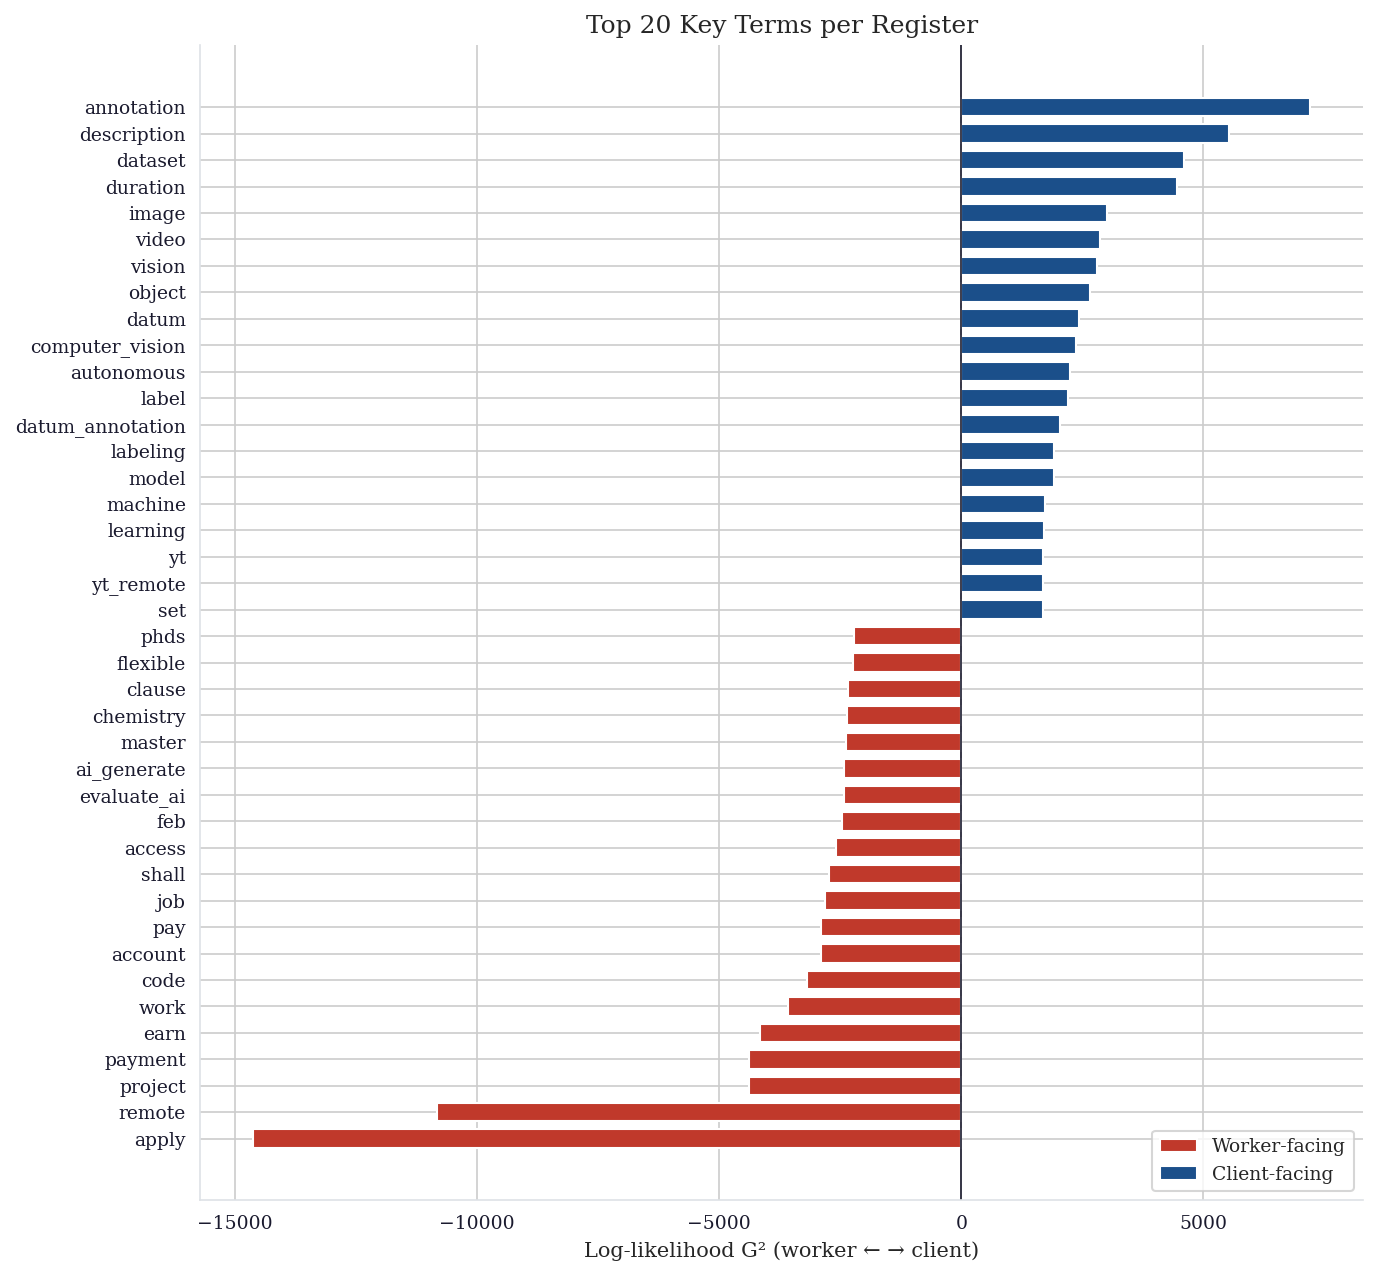

In [15]:
# ── §4.2.1c: Keyness Diverging Bar Chart (Figure 4.2) ─────────────────────

top_n = 20

w = pd.read_sql(f"""
    SELECT term, ll_score AS g2
    FROM keyness_results
    WHERE comparison = 'cross_platform'
      AND rel_freq_worker > 0
    ORDER BY ll_score ASC          -- most negative = most worker-key
    LIMIT {top_n}
""", conn)

c = pd.read_sql(f"""
    SELECT term, ll_score AS g2
    FROM keyness_results
    WHERE comparison = 'cross_platform'
      AND rel_freq_client > 0
    ORDER BY ll_score DESC         -- most positive = most client-key
    LIMIT {top_n}
""", conn)

# No sign flip needed — ll_score is already negative for worker-key terms
combined = pd.concat([w, c]).sort_values('g2')

fig, ax = plt.subplots(figsize=(10, 10))
colors = [C_WORKER if v < 0 else C_CLIENT for v in combined['g2']]
ax.barh(range(len(combined)), combined['g2'], color=colors, height=0.7)
ax.set_yticks(range(len(combined)))
ax.set_yticklabels(combined['term'], fontsize=9)
ax.axvline(0, color=C_TEXT, linewidth=0.8)
ax.set_xlabel('Log-likelihood G² (worker ← → client)', fontsize=10)
ax.set_title(f'Top {top_n} Key Terms per Register', fontsize=12)

legend_elements = [
    mpatches.Patch(facecolor=C_WORKER, label='Worker-facing'),
    mpatches.Patch(facecolor=C_CLIENT, label='Client-facing'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

apply_style(ax)
save_fig(fig, 'fig_42_keyness_diverging_bar')
plt.show()

### §4.2.2 — Term Exclusivity

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


  Saved: ../output/chapter4/fig_43_exclusivity_volcano_final_v2.pdf


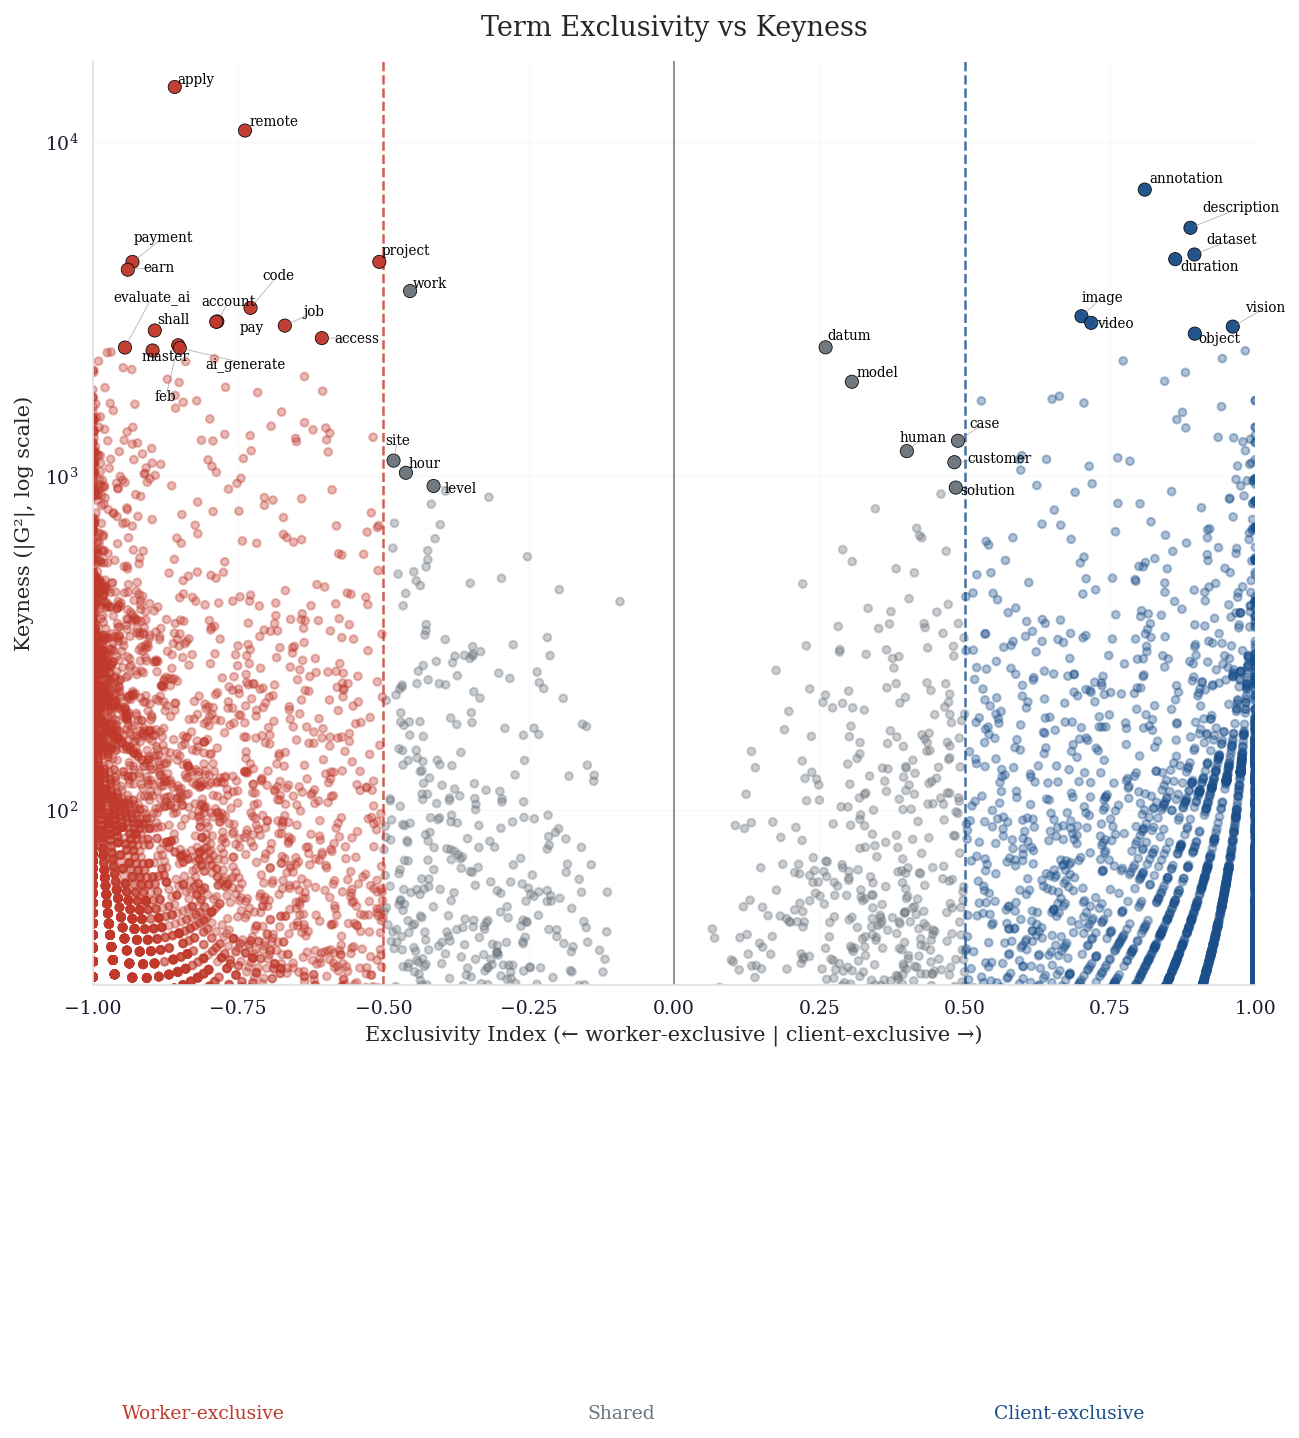


Terms with E < -0.5 (worker-exclusive): 14018
Terms with E > 0.5 (client-exclusive): 8982


In [5]:
# ── §4.x: Exclusivity Volcano Plot (Final Improved) ─────────────────

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from adjustText import adjust_text

# --- LOAD DATA ---
excl = pd.read_sql("""
    SELECT term,
           ll_score,
           rel_freq_worker,
           rel_freq_client,
           ROUND(
               (rel_freq_client - rel_freq_worker) /
               (rel_freq_worker + rel_freq_client), 4
           ) AS exclusivity_index,
           ABS(ll_score) AS g2_abs
    FROM keyness_results
    WHERE comparison = 'cross_platform'
      AND (rel_freq_worker + rel_freq_client) > 0
      AND ABS(ll_score) > 10
""", conn)

# --- LOG SAFETY ---
excl = excl[excl['g2_abs'] > 0]

# --- COLOR ASSIGNMENT ---
def get_color(x):
    if x < -0.5:
        return C_WORKER
    elif x > 0.5:
        return C_CLIENT
    else:
        return C_SHARED

excl['color'] = excl['exclusivity_index'].apply(get_color)

# --- LABEL SELECTION ---
top_g2 = excl.nlargest(25, 'g2_abs')

shared = excl[
    (excl['exclusivity_index'] >= -0.5) &
    (excl['exclusivity_index'] <= 0.5)
]
top_shared = shared.nlargest(10, 'g2_abs')

labels_df = pd.concat([top_g2, top_shared]).drop_duplicates()

# --- FIGURE ---
fig, ax = plt.subplots(figsize=(10, 8))

# --- ALL POINTS ---
ax.scatter(
    excl['exclusivity_index'],
    excl['g2_abs'],
    c=excl['color'],
    s=14,
    alpha=0.35,
    zorder=1
)

# --- HIGHLIGHTED POINTS ---
ax.scatter(
    labels_df['exclusivity_index'],
    labels_df['g2_abs'],
    c=labels_df['color'],
    s=40,
    alpha=0.95,
    edgecolor='black',
    linewidth=0.4,
    zorder=3
)

# --- LOG SCALE ---
ax.set_yscale('log')

# --- LABELS ---
texts = []
for _, row in labels_df.iterrows():
    texts.append(
        ax.text(
            row['exclusivity_index'],
            row['g2_abs'],
            row['term'],
            fontsize=6.5,
            color='black',
            zorder=4
        )
    )

# --- ADJUST LABELS ---
adjust_text(
    texts,
    arrowprops=dict(
        arrowstyle='-',
        color='gray',
        lw=0.4,
        alpha=0.6
    ),
    expand_points=(1.3, 1.5),
    expand_text=(1.3, 1.5),
    force_text=0.6
)

# --- REFERENCE LINES ---
ax.axvline(-0.5, color=C_WORKER, linewidth=1.2, linestyle='--', alpha=0.8)
ax.axvline(0.5,  color=C_CLIENT, linewidth=1.2, linestyle='--', alpha=0.8)
ax.axvline(0,    color='black', linewidth=0.8, alpha=0.5)

# --- THRESHOLD ---
ax.axhline(10, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)

# --- REGION LABELS ---
ax.text(-0.95, 1.5, 'Worker-exclusive', fontsize=9, color=C_WORKER)
ax.text(0.55, 1.5, 'Client-exclusive', fontsize=9, color=C_CLIENT)
ax.text(-0.15, 1.5, 'Shared', fontsize=9, color=C_SHARED)

# --- AXES ---
ax.set_xlim(-1, 1)
ax.set_ylim(30, excl['g2_abs'].max() * 1.2)

ax.set_xlabel(
    'Exclusivity Index (← worker-exclusive | client-exclusive →)',
    fontsize=10
)
ax.set_ylabel('Keyness (|G²|, log scale)', fontsize=10)

ax.set_title(
    'Term Exclusivity vs Keyness',
    fontsize=13,
    pad=12
)

# --- LOG TICKS ---
ax.yaxis.set_major_locator(ticker.LogLocator(base=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10, subs='auto'))
ax.yaxis.set_minor_formatter(ticker.NullFormatter())

# --- GRID ---
ax.grid(True, which='major', linestyle='-', linewidth=0.4, alpha=0.2)
ax.grid(True, which='minor', linestyle=':', linewidth=0.3, alpha=0.15)

# --- CLEAN SPINES ---
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- FREEZE AXIS ---
ax.autoscale(False)

# --- STYLE + SAVE ---
apply_style(ax)
save_fig(fig, 'fig_43_exclusivity_volcano_final_v2')

plt.show()

# --- STATS ---
n_worker_excl = len(excl[excl['exclusivity_index'] < -0.5])
n_client_excl = len(excl[excl['exclusivity_index'] > 0.5])

print(f'\nTerms with E < -0.5 (worker-exclusive): {n_worker_excl}')
print(f'Terms with E > 0.5 (client-exclusive): {n_client_excl}')

  Saved: ../output/chapter4/fig_43_exclusivity_volcano.pdf


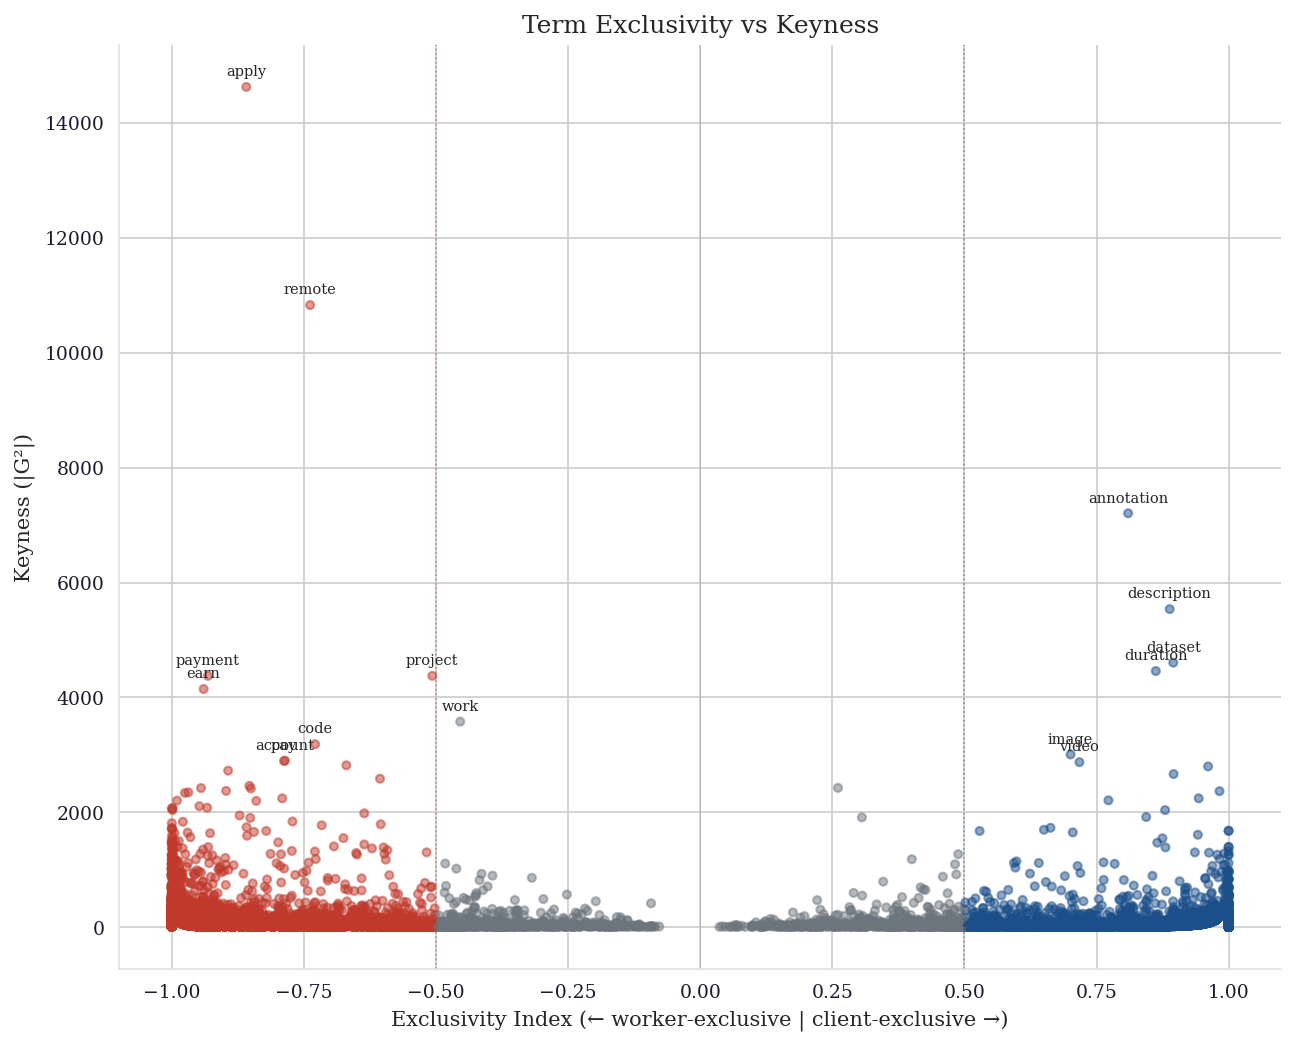


Terms with E < -0.5 (worker-exclusive): 14018
Terms with E > 0.5 (client-exclusive): 8982


In [17]:
# ── §4.x: Exclusivity Volcano Plot (Figure 4.3) ─────────────────────

excl = pd.read_sql("""
    SELECT term,
           ll_score,
           rel_freq_worker,
           rel_freq_client,
           ROUND(
               (rel_freq_client - rel_freq_worker) /
               (rel_freq_worker + rel_freq_client), 4
           ) AS exclusivity_index,
           ABS(ll_score) AS g2_abs
    FROM keyness_results
    WHERE comparison = 'cross_platform'
      AND (rel_freq_worker + rel_freq_client) > 0
      AND ABS(ll_score) > 10
""", conn)

fig, ax = plt.subplots(figsize=(10, 8))

colors = []
for _, row in excl.iterrows():
    if row['exclusivity_index'] < -0.5:
        colors.append(C_WORKER)
    elif row['exclusivity_index'] > 0.5:
        colors.append(C_CLIENT)
    else:
        colors.append(C_SHARED)

ax.scatter(excl['exclusivity_index'], excl['g2_abs'],
           c=colors, s=15, alpha=0.5, zorder=2)

# Label top terms by absolute keyness strength
top = excl.nlargest(15, 'g2_abs')
for _, row in top.iterrows():
    ax.annotate(row['term'], (row['exclusivity_index'], row['g2_abs']),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 4), textcoords='offset points')

ax.axvline(-0.5, color=C_WORKER, linewidth=0.8, linestyle=':', alpha=0.5)
ax.axvline(0.5,  color=C_CLIENT, linewidth=0.8, linestyle=':', alpha=0.5)
ax.axvline(0,    color=C_SHARED, linewidth=0.5, alpha=0.3)

ax.set_xlabel('Exclusivity Index (← worker-exclusive | client-exclusive →)', fontsize=10)
ax.set_ylabel('Keyness (|G²|)', fontsize=10)
ax.set_title('Term Exclusivity vs Keyness', fontsize=12)

apply_style(ax)
save_fig(fig, 'fig_43_exclusivity_volcano')
plt.show()

# Stats for text
n_worker_excl = len(excl[excl['exclusivity_index'] < -0.5])
n_client_excl = len(excl[excl['exclusivity_index'] > 0.5])
print(f'\nTerms with E < -0.5 (worker-exclusive): {n_worker_excl}')
print(f'Terms with E > 0.5 (client-exclusive): {n_client_excl}')

### §4.2.3 — Co-occurrence Analysis

The keyness and exclusivity analyses identified *which* terms diverge across
registers. Co-occurrence analysis addresses a different question: when the
two registers use the *same* term, do they activate the same semantic frame?
PMI profiles of a small set of anchor terms (`human`, `worker`, `work`, plus
automation seed terms) are compared across the client-facing and
worker-facing sub-corpora.

The purpose of this section is deliberately restricted. The PMI profiles are
treated here as *signposts* rather than as end-point interpretations: they
indicate which terms show the largest register divergence, and they identify
candidate pages for close reading in the Step-2 deep-reading analysis
(§4.4). Interpretation of individual collocates is deferred to that section,
where it can be grounded in KWIC passages and topic-model evidence.

Two simple filters are applied before plotting to guard against artefacts
identified in a preliminary diagnostic pass: a small blocklist of known
boilerplate / lemmatiser-truncation tokens (see `COOC_BLOCKLIST` in the
configuration cell), and a minimum-domain-diversity threshold requiring each
pair to appear across at least `COOC_MIN_DOMAINS` distinct platforms. The
combined filter strips out, for example, the eleven near-duplicate dataset
pages on humansintheloop.org whose shared licence footer had inflated
single-domain collocates of *human*.


Built page index: 3,034 pages cached
  human/client: raw=20 after blocklist=18 after domain≥3=16
  human/worker: raw=20 after blocklist=20 after domain≥3=2
human client: 10 rows, worker: 10 rows
  Saved: ../output/chapter4/fig_44_cooc_human_comparison.pdf


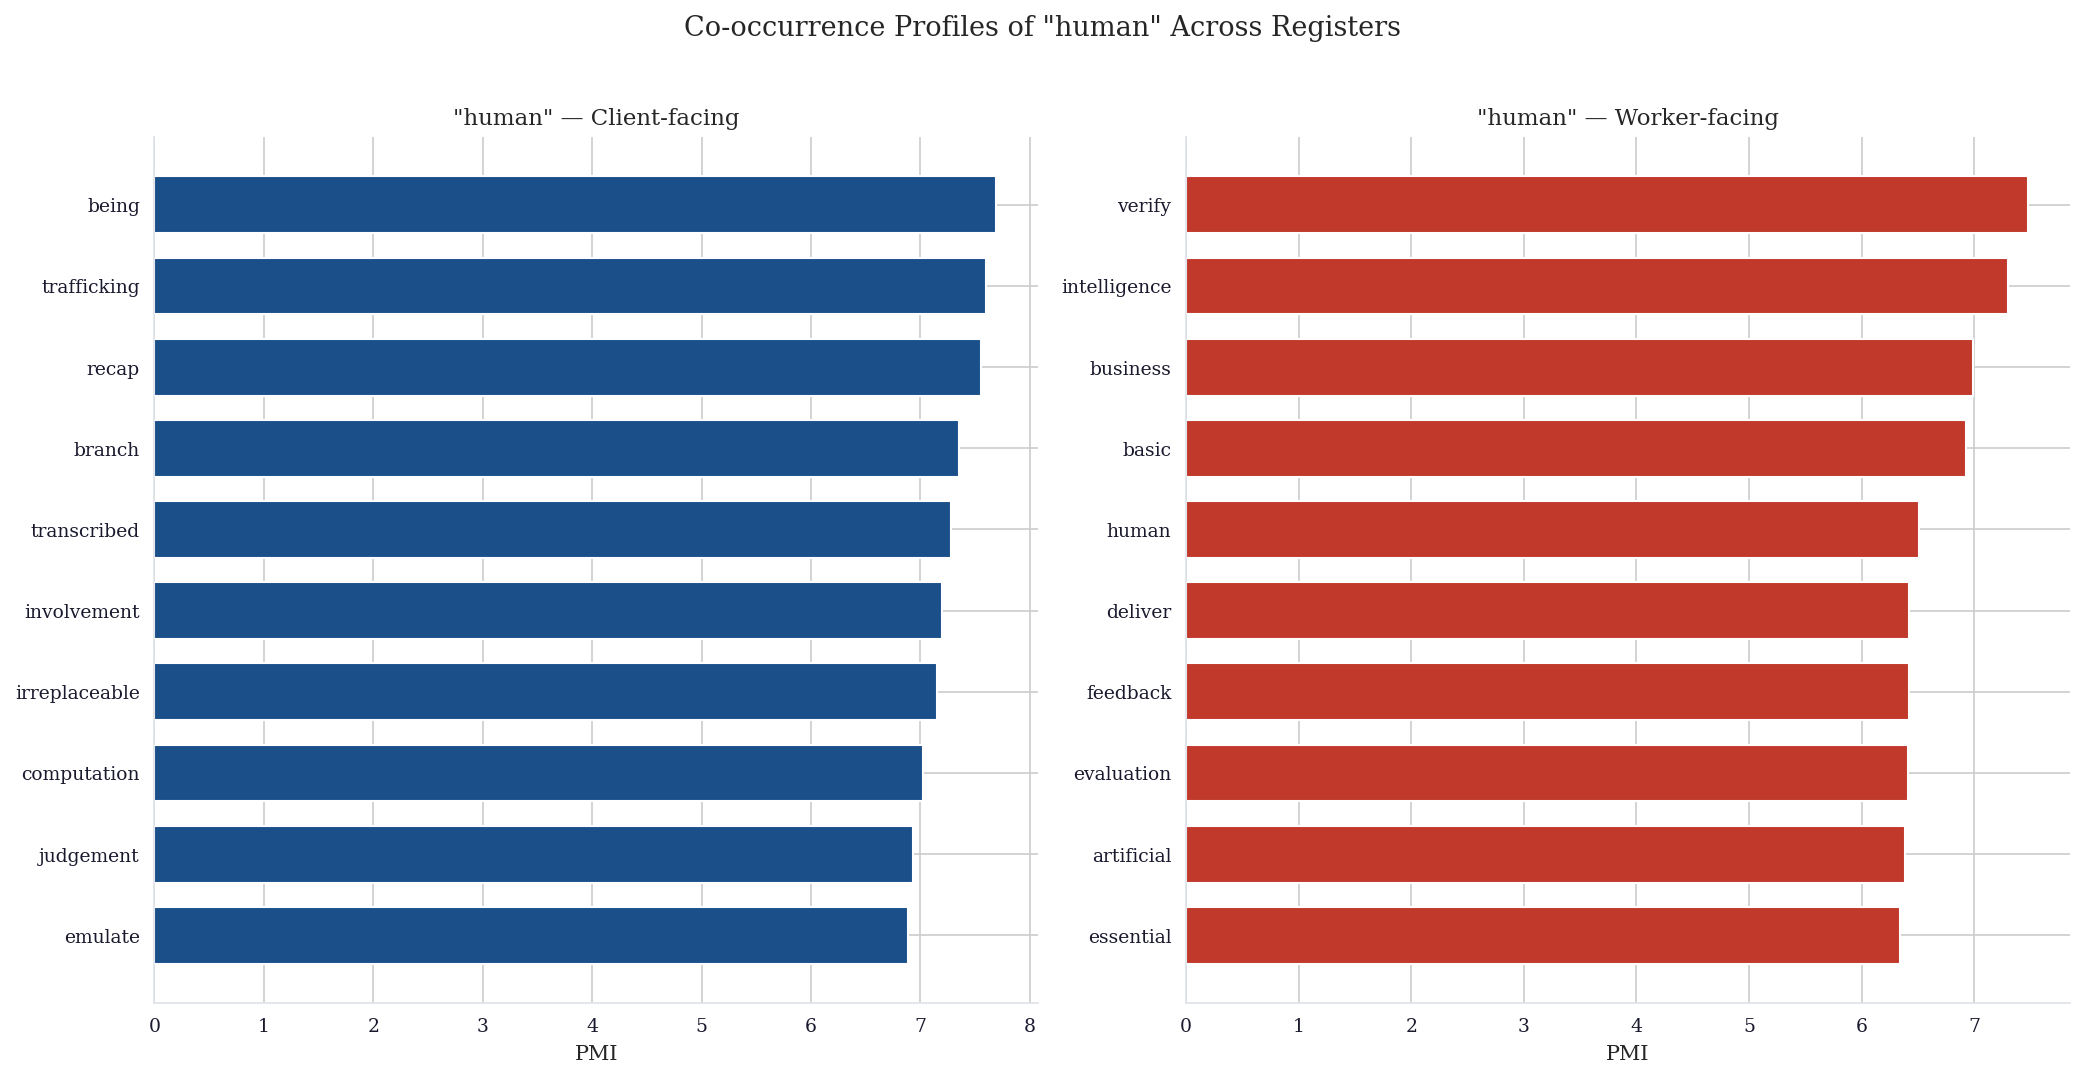

In [11]:
# ── §4.2.3a: PMI helper (boilerplate + cross-domain filter) ────────────
# Uses the real schema: pages_tfidf (JSON unigrams) joined to pages,
# websites, and platforms. `cooccurrence_results` supplies the PMI; the
# filter logic re-scans pages_tfidf to verify cross-domain support.

import json as _json

# One-time build of an in-memory page index: page_id -> (domain, audience,
# set(unigrams)). Avoids re-parsing JSON on every call.
_PAGE_INDEX = None

def _build_page_index():
    """Cache page-level token sets once. Returns dict[page_id] ->
    {'domain': str, 'audience': str, 'tokens': set[str]}."""
    rows = conn.execute("""
        SELECT pt.page_id, w.domain, pl.audience, pt.unigrams
        FROM pages_tfidf pt
        JOIN pages p       ON pt.page_id = p.id
        JOIN websites w    ON p.website_id = w.id
        JOIN platforms pl  ON w.domain = pl.domain
        WHERE pt.unigrams IS NOT NULL
          AND pl.audience IN ('client', 'worker')
    """).fetchall()
    idx = {}
    for r in rows:
        try:
            toks = _json.loads(r['unigrams'])
        except Exception:
            continue
        idx[r['page_id']] = {
            'domain': r['domain'],
            'audience': r['audience'],
            'tokens': set(toks),
        }
    return idx


def _ensure_index():
    global _PAGE_INDEX
    if _PAGE_INDEX is None:
        _PAGE_INDEX = _build_page_index()
        print(f'Built page index: {len(_PAGE_INDEX):,} pages cached')
    return _PAGE_INDEX


def _domain_support(term, coll, audience):
    """Distinct domains where (term, coll) co-occur in audience pages."""
    idx = _ensure_index()
    domains = set()
    for meta in idx.values():
        if meta['audience'] != audience:
            continue
        if term in meta['tokens'] and coll in meta['tokens']:
            domains.add(meta['domain'])
    return domains


def _filter_by_domain_support(rows, term, audience, min_domains):
    if min_domains <= 1 or not rows:
        return rows
    kept = []
    for r in rows:
        n_dom = len(_domain_support(term, r['collocate'], audience))
        r['n_domains'] = n_dom
        if n_dom >= min_domains:
            kept.append(r)
    return kept


def get_pmi_profile(term, audience, top_n=10, min_len=3, min_cofreq=5,
                    apply_filter=True):
    """Top PMI collocates for `term` in `audience`, with boilerplate
    and cross-domain filtering. Returns a pandas DataFrame."""
    pool = 4 * top_n   # generous pool so the filter has room to cut
    rows = conn.execute("""
        SELECT collocate, pmi, cofreq
        FROM cooccurrence_results
        WHERE focus_term = ?
          AND audience   = ?
          AND comparison = 'cross_platform'
          AND LENGTH(collocate) >= ?
          AND cofreq     >= ?
        ORDER BY pmi DESC
        LIMIT ?
    """, (term, audience, min_len, min_cofreq, pool)).fetchall()
    rows = [dict(r) for r in rows]
    if apply_filter:
        rows = [r for r in rows if r['collocate'] not in COOC_BLOCKLIST]
        rows = _filter_by_domain_support(rows, term, audience, COOC_MIN_DOMAINS)
    rows = rows[:top_n]
    return pd.DataFrame(rows, columns=['collocate', 'pmi', 'cofreq'])


def plot_pmi_comparison(term, client_df, worker_df, fig_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharey=False)
    if len(client_df) > 0:
        ax1.barh(range(len(client_df)), client_df['pmi'],
                 color=C_CLIENT, height=0.7)
        ax1.set_yticks(range(len(client_df)))
        ax1.set_yticklabels(client_df['collocate'], fontsize=9)
        ax1.invert_yaxis()
    ax1.set_title(f'"{term}" — Client-facing', fontsize=11)
    ax1.set_xlabel('PMI', fontsize=10)
    apply_style(ax1)
    if len(worker_df) > 0:
        ax2.barh(range(len(worker_df)), worker_df['pmi'],
                 color=C_WORKER, height=0.7)
        ax2.set_yticks(range(len(worker_df)))
        ax2.set_yticklabels(worker_df['collocate'], fontsize=9)
        ax2.invert_yaxis()
    ax2.set_title(f'"{term}" — Worker-facing', fontsize=11)
    ax2.set_xlabel('PMI', fontsize=10)
    apply_style(ax2)
    fig.suptitle(f'Co-occurrence Profiles of "{term}" Across Registers',
                 fontsize=13, y=1.02)
    fig.tight_layout()
    save_fig(fig, fig_name)
    plt.show()


# Sanity check before plotting — prints the raw pool, the blocklist
# effect, and the domain-support effect for `human`. If these are all
# zero, the upstream cooccurrence_results table or the page index is
# empty; inspect before proceeding.
def diagnose(term='human'):
    for aud in ['client', 'worker']:
        raw = conn.execute("""
            SELECT collocate, pmi FROM cooccurrence_results
            WHERE focus_term=? AND audience=? AND comparison='cross_platform'
            ORDER BY pmi DESC LIMIT 20
        """, (term, aud)).fetchall()
        raw = [dict(r) for r in raw]
        after_block = [r for r in raw if r['collocate'] not in COOC_BLOCKLIST]
        after_dom = _filter_by_domain_support(after_block, term, aud, COOC_MIN_DOMAINS)
        print(f'  {term}/{aud}: raw={len(raw)} '
              f'after blocklist={len(after_block)} '
              f'after domain≥{COOC_MIN_DOMAINS}={len(after_dom)}')

diagnose('human')

# Shared container for profiles — consumed by the sampling cell below.
COOC_PROFILES = {}

# ── Human ──────────────────────────────────────────────────────────────────
FOCUS_TERM = 'human'
COOC_N = 10
client_df = get_pmi_profile(FOCUS_TERM, 'client', COOC_N)
worker_df = get_pmi_profile(FOCUS_TERM, 'worker', COOC_N)
COOC_PROFILES[FOCUS_TERM] = {'client': client_df, 'worker': worker_df}
print(f'human client: {len(client_df)} rows, worker: {len(worker_df)} rows')
plot_pmi_comparison(FOCUS_TERM, client_df, worker_df, 'fig_44_cooc_human_comparison')


  Saved: ../output/chapter4/fig_44b_cooc_worker_comparison.pdf


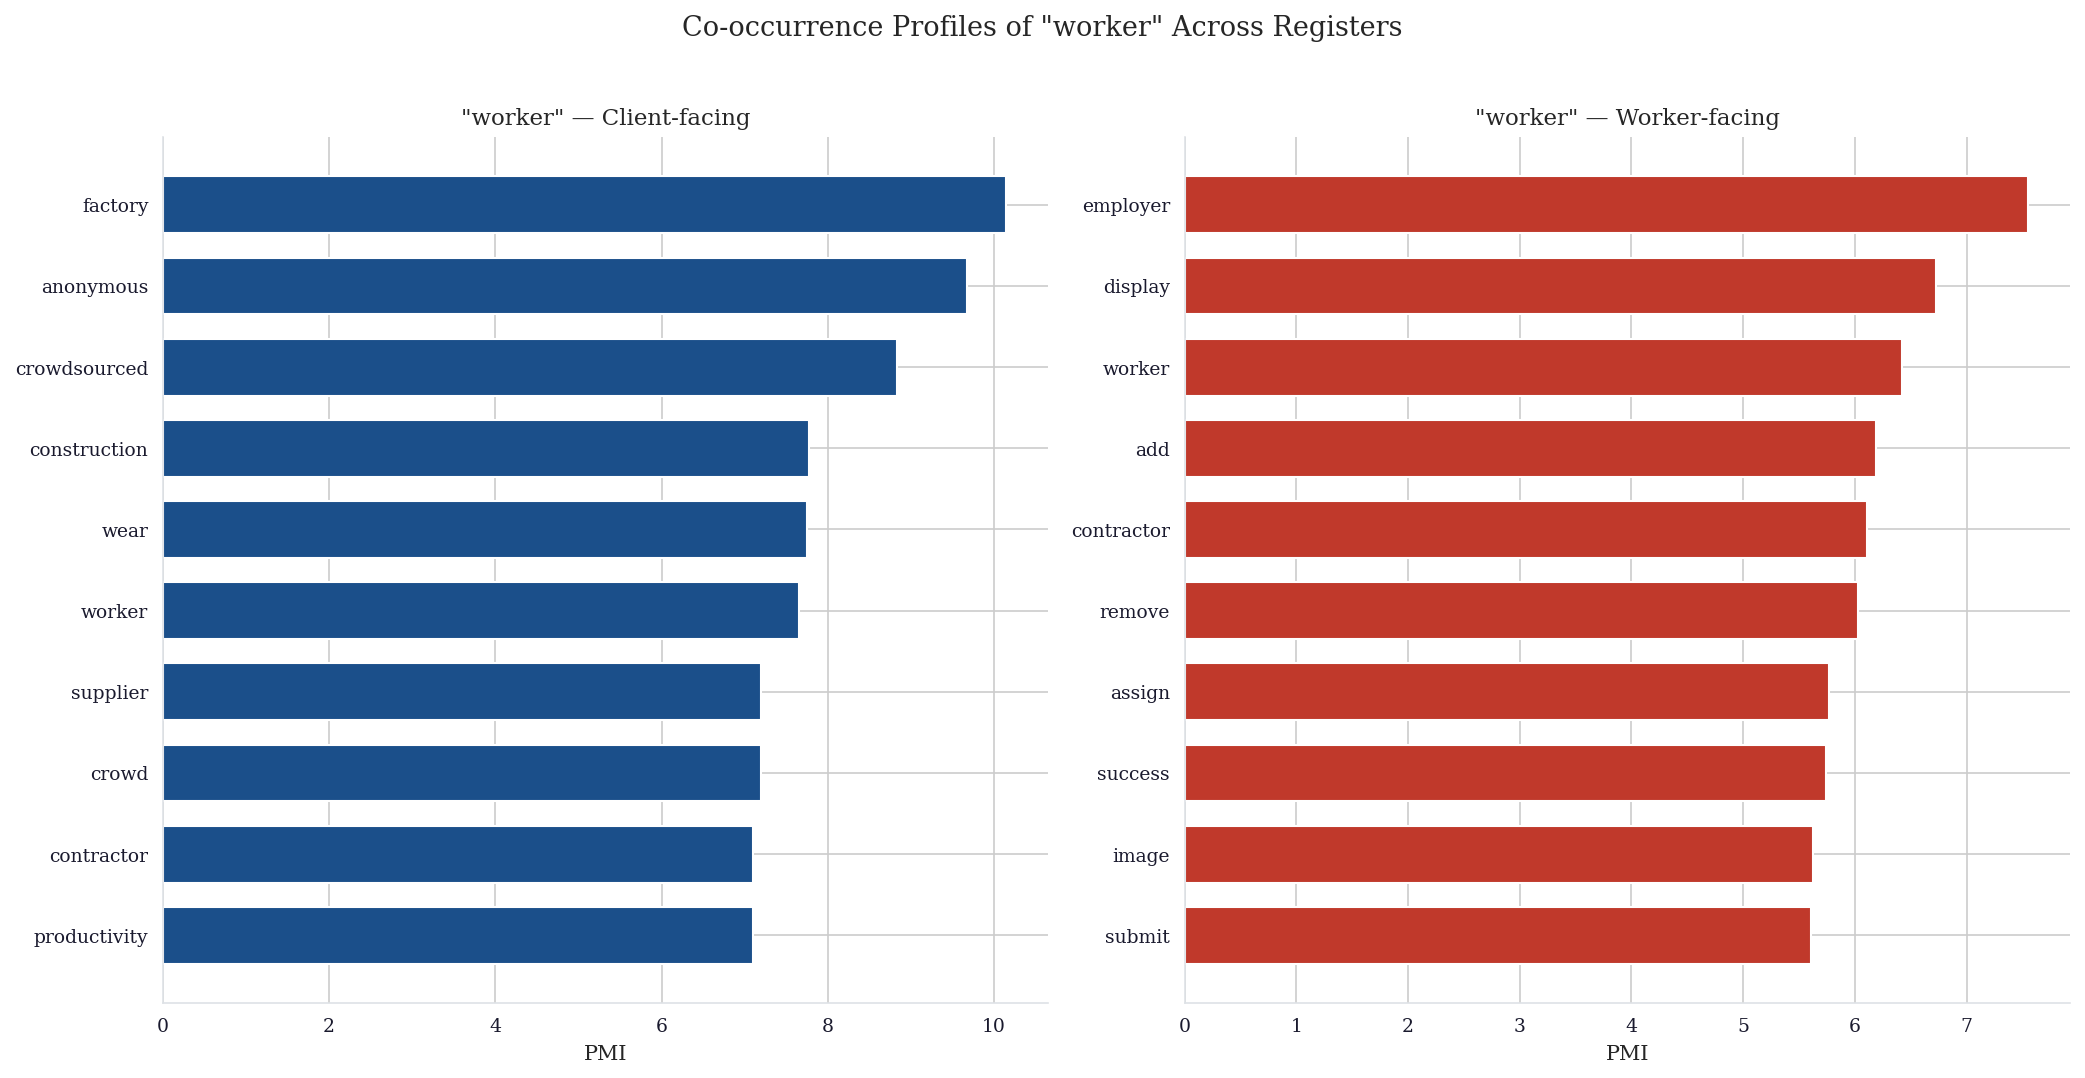

In [13]:
# ── §4.2.3b: "worker" PMI Profile (filtered) ─────────────────────────────
FOCUS_TERM = 'worker'
COOC_N = 10
client_df = get_pmi_profile(FOCUS_TERM, 'client', COOC_N)
worker_df = get_pmi_profile(FOCUS_TERM, 'worker', COOC_N)
COOC_PROFILES[FOCUS_TERM] = {'client': client_df, 'worker': worker_df}
plot_pmi_comparison(FOCUS_TERM, client_df, worker_df, 'fig_44b_cooc_worker_comparison')


  Saved: ../output/chapter4/fig_44c_cooc_work_comparison.pdf


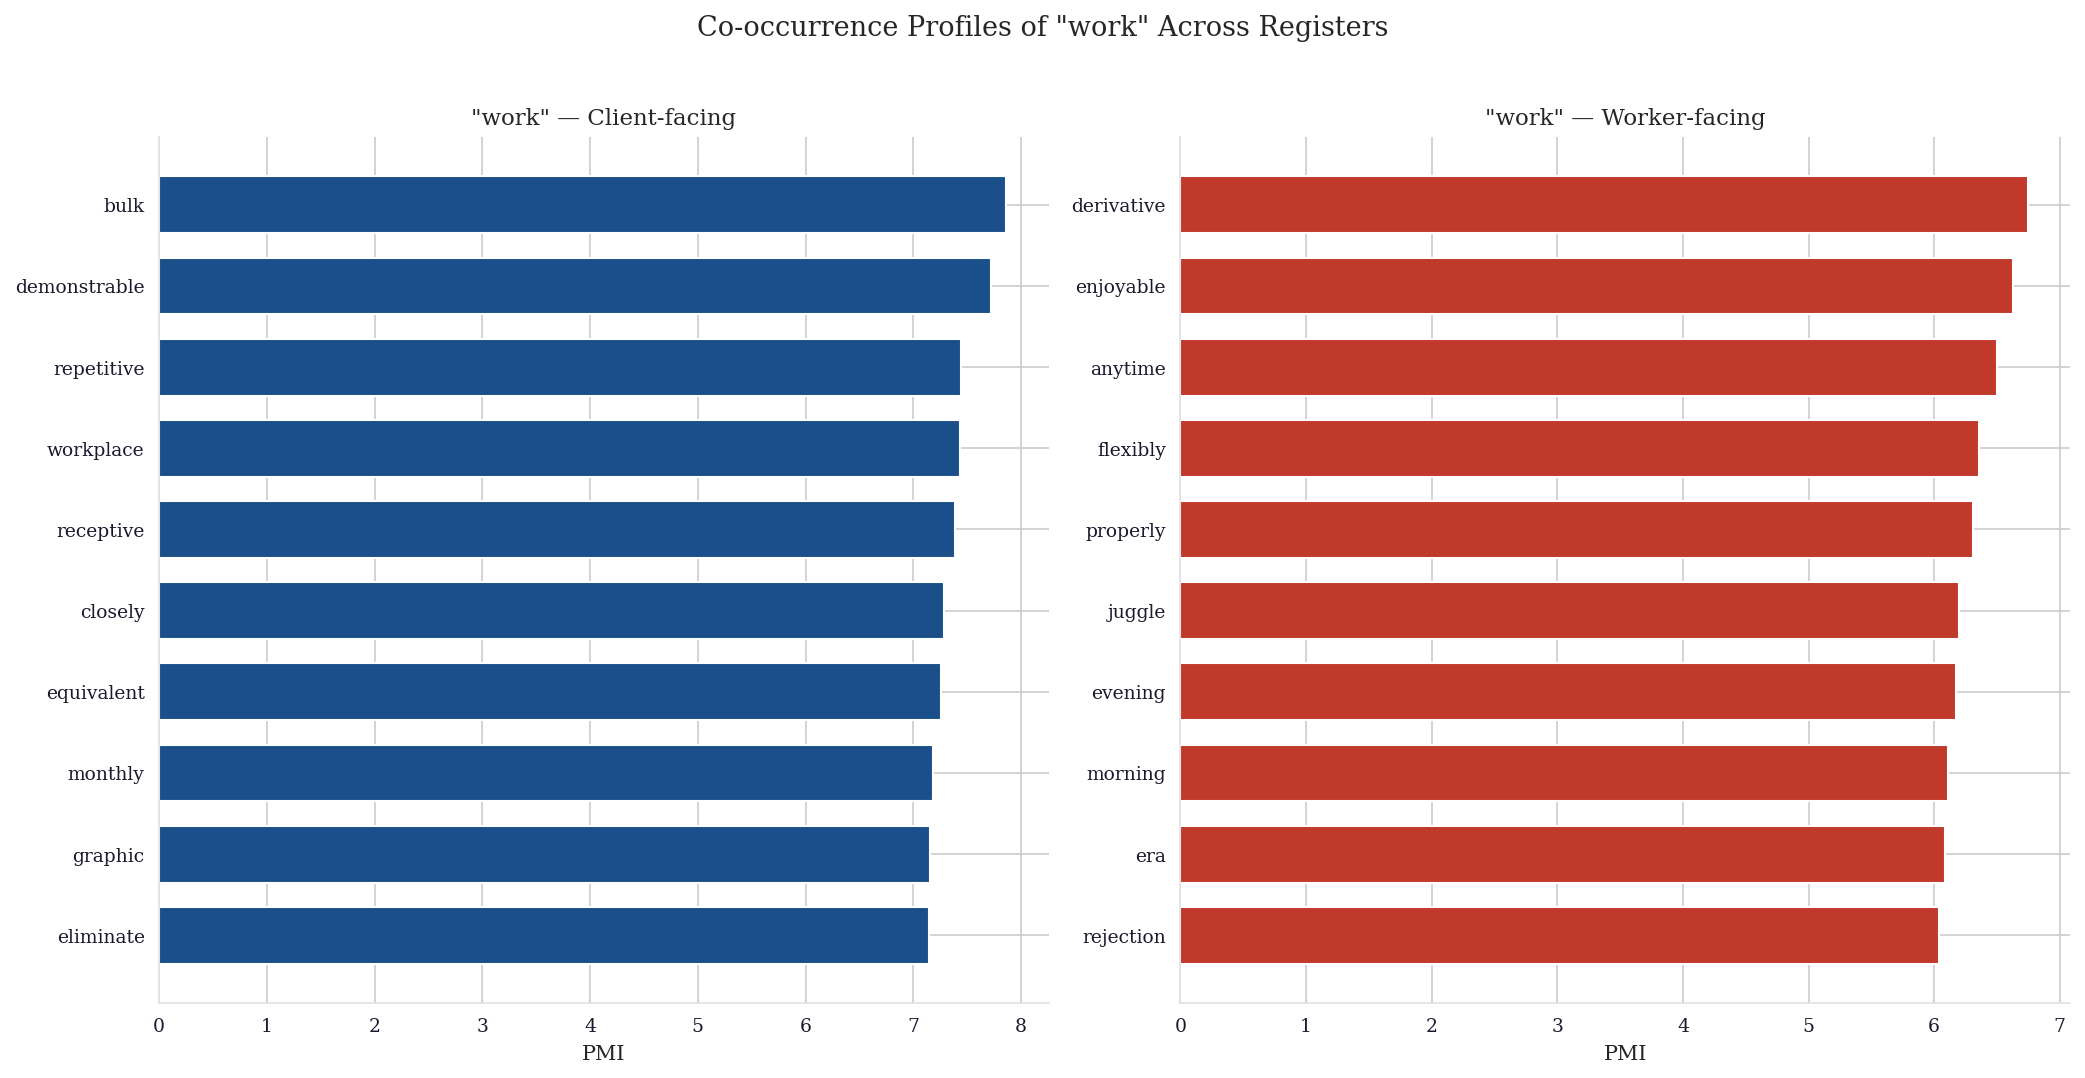

In [14]:
# ── §4.2.3c: "work" PMI Profile (filtered) ───────────────────────────────
FOCUS_TERM = 'work'
COOC_N = 10
client_df = get_pmi_profile(FOCUS_TERM, 'client', COOC_N)
worker_df = get_pmi_profile(FOCUS_TERM, 'worker', COOC_N)
COOC_PROFILES[FOCUS_TERM] = {'client': client_df, 'worker': worker_df}
plot_pmi_comparison(FOCUS_TERM, client_df, worker_df, 'fig_44c_cooc_work_comparison')


In [21]:
# ── §4.2.3d: Automation Terms PMI Profiles (filtered) ─────────────────────
AUTO_TERMS = ['annotator', 'contributor', 'resource', 'AI', 'automation', 'algorithm', 'model', 'quality', 'accuracy', 'trust', 'task', 'project', 'solution', 'platform', "worker", "labour", "task", "job", "pay", "earn",
    "autonomous", "machine", "automate", "intelligent", "automation",
    "human", "quality", "oversight", "annotation", "label",
    # Additional terms for H2–H4
    "flexible", "flexibility", "freedom", "autonomy",
    "talent", "resource", "contributor", "workforce",
    "community", "collective", "score", "rating", "rank",
    "earn", "wage", "salary", "payment", "bonus", "rate", "income", "fee", "compensation", "paid",
    "hour", "schedule", "deadline", "flexible", "available", "shift", "weekend", "full-time", "part-time", "anytime",
    "ethical", "responsible", "fair", "transparent", "safety", "wellbeing", "dignity", "sustainable", "principle", "accountability",
    "visible", "invisible", "hidden", "behind", "anonymous", "named", "recognised", "credit", "attribution", "byline"]

for term in AUTO_TERMS:
    client_prof = get_pmi_profile(term, 'client', 10)
    worker_prof = get_pmi_profile(term, 'worker', 10)
    if len(client_prof) == 0 and len(worker_prof) == 0:
        print(f'  No co-occurrence data for "{term}" — skipping')
        continue
    COOC_PROFILES[term] = {'client': client_prof, 'worker': worker_prof}
    print(f'\n=== "{term}" ===')
    if len(client_prof):
        print(f'  Client top: {", ".join(client_prof["collocate"].tolist()[:8])}')
    if len(worker_prof):
        print(f'  Worker top: {", ".join(worker_prof["collocate"].tolist()[:8])}')


  No co-occurrence data for "annotator" — skipping

=== "contributor" ===
  Client top: crowd, agility, contributor, member, native, modality, clarity, country
  Worker top: empower, trade, advance, faqs, year, technology, shape, list

=== "resource" ===
  Client top: utilization, podcast, allocation, aerial, statement, divert, allocate, surveillance
  Worker top: scientist, home, course, career, science, improve, free, evaluate
  No co-occurrence data for "AI" — skipping

=== "automation" ===
  Client top: hidden, rpa, culture, uncomfortable, office, telecom, related, mission
  No co-occurrence data for "algorithm" — skipping
  No co-occurrence data for "model" — skipping

=== "quality" ===
  Client top: assurance, sacrifice, redefine, spec, king, german, impress, high
  Worker top: assurance, appreciate, reviewer, engine, volume, bonus, relevance, high
  No co-occurrence data for "accuracy" — skipping
  No co-occurrence data for "trust" — skipping

=== "task" ===
  Client top: mundan

#### §4.2.3e — From co-occurrence signposts to Step-2 sampling

The filtered PMI profiles above identify the register-divergent term pairs.
The cell below converts those profiles into a concrete sampling frame for
the Step-2 close reading (§4.4): for each top (focus, collocate, audience)
triple, it retrieves every page in which both tokens co-occur and writes a
CSV of candidate passages. This is the mechanism by which the exploratory
lexical results in §4.2 *constrain* the interpretive reading that follows,
rather than being interpreted in isolation here.


In [16]:
# ── §4.2.3e: Sampling frame for Step 2 (close reading) ────────────────────
# Uses the cached _PAGE_INDEX built by the helper cell above, plus a
# lookup of (page_id -> url) from the pages table. Outputs:
#   sampling_frame.csv         — one row per candidate passage
#   sampling_frame_summary.csv — one row per (focus, collocate, audience)

SAMPLING_TOP_K = 5   # top collocates per (term, audience) to seed

_ensure_index()

# Lookup page_id -> url, domain for output.
_PAGE_META = {r['id']: {'url': r['url'], 'domain': r['domain']}
              for r in conn.execute("""
                  SELECT p.id, p.url, w.domain
                  FROM pages p JOIN websites w ON p.website_id = w.id
              """).fetchall()}

def pages_with_pair(focus, coll, audience):
    out = []
    for pid, meta in _PAGE_INDEX.items():
        if meta['audience'] != audience:
            continue
        if focus in meta['tokens'] and coll in meta['tokens']:
            page_meta = _PAGE_META.get(pid, {})
            out.append({
                'page_id': pid,
                'domain': meta['domain'],
                'url': page_meta.get('url', ''),
            })
    return out


frame_rows, summary_rows = [], []
for term, profiles in COOC_PROFILES.items():
    for audience, df in profiles.items():
        if df is None or len(df) == 0:
            continue
        for rank, (_, row) in enumerate(df.head(SAMPLING_TOP_K).iterrows(), 1):
            coll = row['collocate']
            pages = pages_with_pair(term, coll, audience)
            summary_rows.append({
                'focus_term': term,
                'collocate': coll,
                'audience': audience,
                'rank': rank,
                'pmi': round(float(row['pmi']), 3),
                'n_pages': len(pages),
                'n_domains': len({p['domain'] for p in pages}),
            })
            for p in pages:
                frame_rows.append({
                    'focus_term': term,
                    'collocate': coll,
                    'audience': audience,
                    'rank': rank,
                    'pmi': round(float(row['pmi']), 3),
                    **p,
                })

frame_df = pd.DataFrame(frame_rows)
summary_df = pd.DataFrame(summary_rows)

frame_path = FIG_DIR / 'sampling_frame.csv'
summary_path = FIG_DIR / 'sampling_frame_summary.csv'
frame_df.to_csv(frame_path, index=False)
summary_df.to_csv(summary_path, index=False)

print(f'Wrote {len(frame_df)} candidate passages -> {frame_path.name}')
print(f'Wrote {len(summary_df)} triples          -> {summary_path.name}')
if len(summary_df):
    print()
    print('Top triples by rank (rank 1 in each audience):')
    display(summary_df[summary_df['rank'] == 1]
            .sort_values(['focus_term', 'audience']))


Wrote 3032 candidate passages -> sampling_frame.csv
Wrote 55 triples          -> sampling_frame_summary.csv

Top triples by rank (rank 1 in each audience):


,focus_term,collocate,audience,rank,pmi,n_pages,n_domains
0,human,being,client,1,7.693,13,3
5,human,verify,worker,1,7.476,41,5
30,intelligent,perceive,client,1,7.659,10,6
35,quality,assurance,client,1,7.642,254,7
40,quality,assurance,worker,1,8.014,16,3
45,task,mundane,client,1,7.617,24,5
50,task,ended,worker,1,6.525,10,3
20,work,bulk,client,1,7.865,19,5
25,work,derivative,worker,1,6.744,8,5
10,worker,factory,client,1,10.149,98,3


---
## §4.3 — Thematic Structure: Structural Topic Model

In [6]:
# ── §4.3.0: Check STM tables exist ────────────────────────────────────────

stm_tables = {'stm_theta', 'stm_topic_terms', 'stm_prevalence'}
missing = stm_tables - tables
if missing:
    print(f'MISSING STM tables: {missing}')
    print('Run 03b_import_stm.py first.')
else:
    print('All STM tables present.')
    n_topics = conn.execute('SELECT COUNT(DISTINCT topic_id) FROM stm_topic_terms').fetchone()[0]
    print(f'Number of topics: {n_topics}')

All STM tables present.
Number of topics: 25


In [7]:

# ---------------------------------------------------------------------
# CELL §4.3.0  — Shared setup (labels, audience palette, topic_df)
# ---------------------------------------------------------------------

TOPIC_LABELS = {
    1:  'Freelance gig & tutor opportunity posts',
    2:  'Survey & research panels',
    3:  'NLP task vocabulary',
    4:  'B2B outsourcing myth/marketing',
    5:  'Developer/code AI training tasks',
    6:  'AI governance & oversight',
    7:  'LLM evaluation & fine-tuning',
    8:  'Cookie & tracking notices',
    9:  'Computer-vision product vocab',
    10: 'Legal & arbitration boilerplate',
    11: 'Worker payments & earnings',
    12: 'Vetted-workforce sales copy',
    13: 'Government & compliance hiring',
    14: 'Expert specialist recruitment',
    15: 'Enterprise partnerships',
    16: 'Workforce-as-resource sales',
    17: 'Worker annotation tooling',
    18: 'Conversational AI thought-leadership',
    19: 'Speech & audio data collection',
    20: 'Autonomous vehicles & drone sensing',
    21: 'AI deployment & synthetic data',
    22: 'Microwork platform campaigns',
    23: 'Medical annotation vertical',
    24: 'SEO & crowdsource tagging',
    25: 'ML architecture concepts',
}

# Hypothesis coding (used ONLY in §4.4 below)
TOPIC_HYPOTHESIS = {
    1:  'H1a',  2:  'H1b',  3:  None, 4:  'H1b',  5:  'H1a',
    6:  'H1c',  7:  'H1b',  8:  None, 9:  'H1b',  10: None,
    11: 'H1a',  12: 'H1c',  13: None, 14: 'H1a',  15: None,
    16: 'H1b',  17: 'H1a',  18: 'H1b', 19: 'H1b',  20: 'H1b',
    21: 'H1b',  22: 'H1a',  23: 'H1b', 24: 'H1b',  25: 'H1b',
}

# Audience palette — empirical only.  CI-crosses-zero gets a faintly
# tinted grey so the sign of the point estimate is still legible.
AUD_WORKER     = '#C04A3A'
AUD_CLIENT     = '#2F5EA8'
AUD_SHARED     = '#888888'
AUD_SHARED_W   = '#A37A70'
AUD_SHARED_C   = '#6A7A9A'

def audience_colour(row):
    if row['significant']:
        return AUD_WORKER if row['estimate'] > 0 else AUD_CLIENT
    return AUD_SHARED_W if row['estimate'] > 0 else AUD_SHARED_C

# Consolidated topic-level dataframe reused by all cells.
_prev = pd.read_sql("""
    SELECT topic_id, estimate, std_err, ci_lower, ci_upper, significant
    FROM stm_prevalence
""", conn)
_theta_mean = pd.read_sql(
    "SELECT topic_id, AVG(theta) AS mean_theta FROM stm_theta GROUP BY topic_id",
    conn)
topic_df = _prev.merge(_theta_mean, on='topic_id')
topic_df['label']      = topic_df['topic_id'].map(TOPIC_LABELS)
topic_df['hypothesis'] = topic_df['topic_id'].map(TOPIC_HYPOTHESIS)  # for §4.4 only
topic_df['colour']     = topic_df.apply(audience_colour, axis=1)
topic_df['direction']  = np.where(topic_df['significant'],
                                  np.where(topic_df['estimate'] > 0, 'W', 'C'),
                                  'S')

print(f'topic_df: {len(topic_df)} topics · '
      f'direction counts: {topic_df.direction.value_counts().to_dict()}')

topic_df: 25 topics · direction counts: {'C': 17, 'W': 7, 'S': 1}


  Saved: ../output/chapter4/fig_46_stm_prevalence_forest.pdf


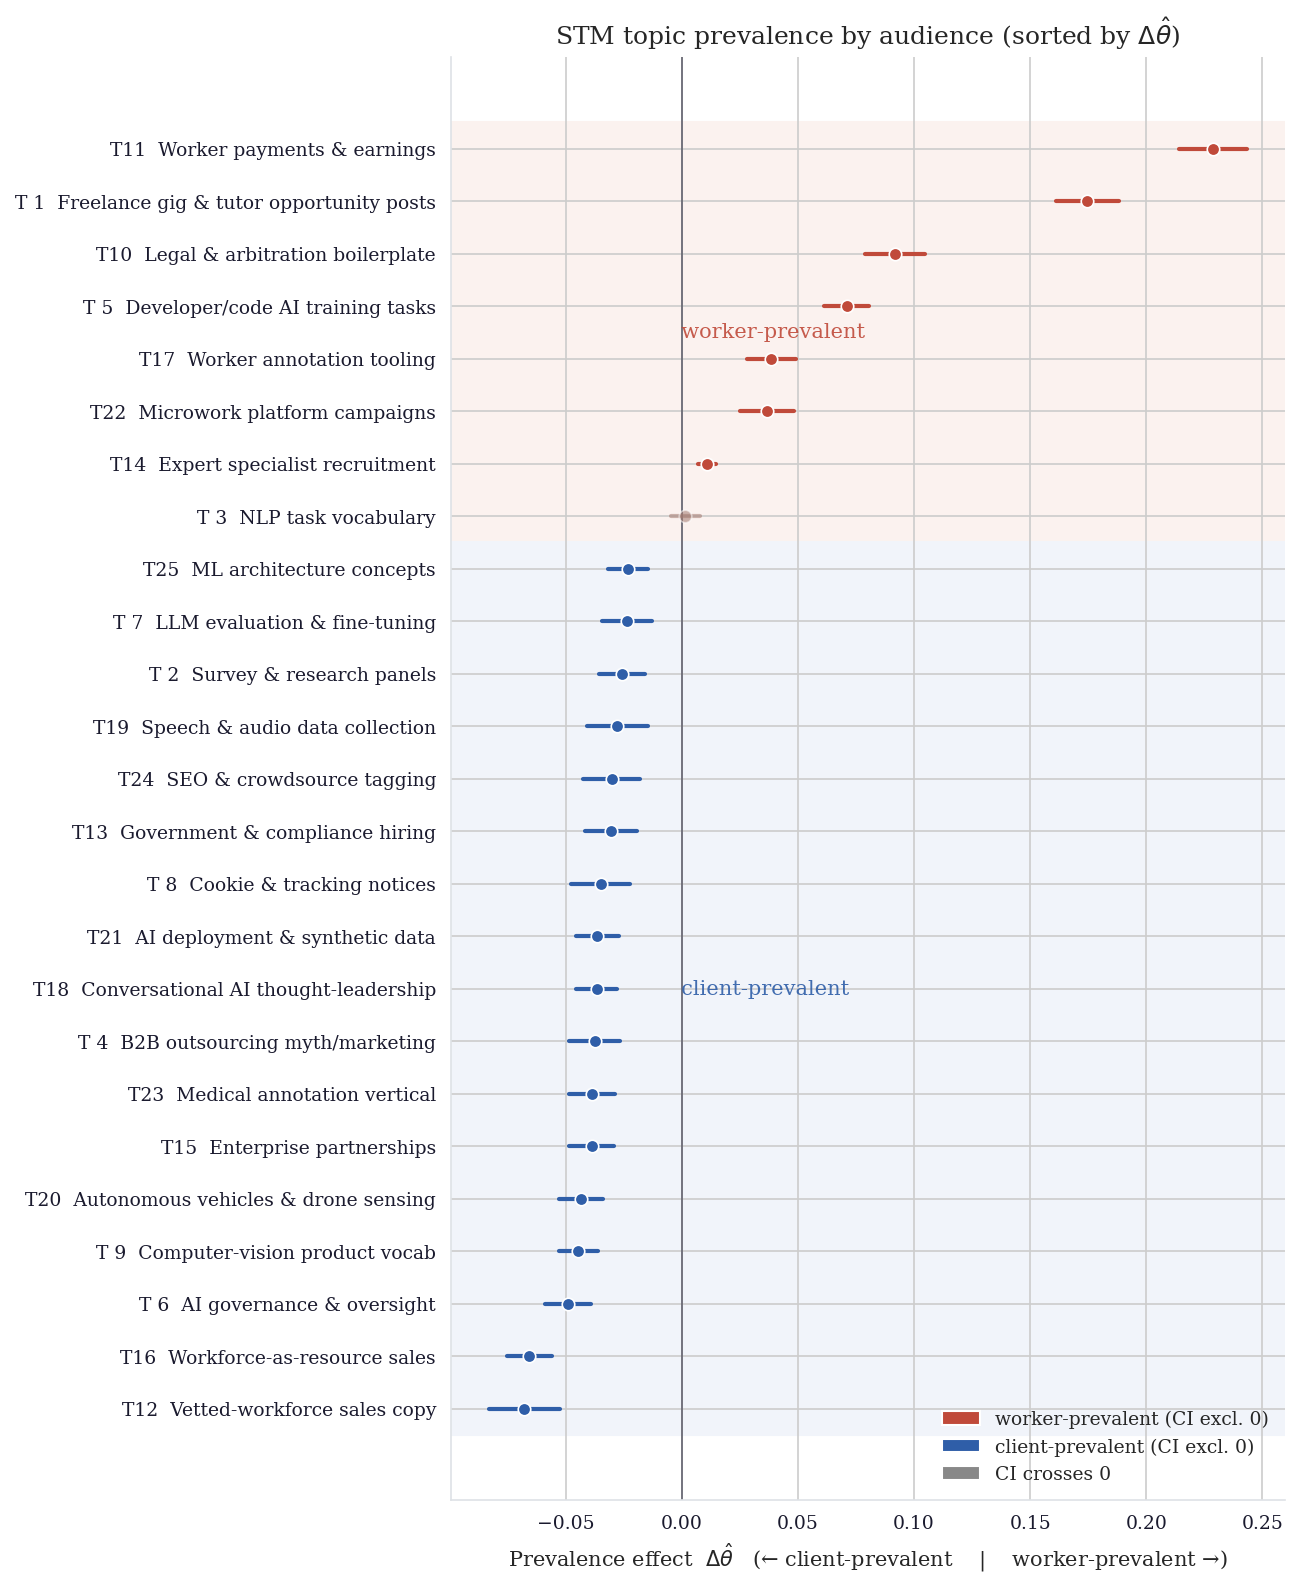

In [8]:
# =====================================================================
# CELL §4.3.1  —  Figure 4.6: Forest plot of Δθ̂
# =====================================================================
# Empirical organization only: rows sorted by Δθ̂ (most worker-
# prevalent at top, most client-prevalent at bottom).  Audience-only
# colouring.  No hypothesis bands, no hypothesis labels.

ordered = topic_df.sort_values('estimate', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10.5, 12.5))

# A faint horizontal band marks the worker-side / client-side split
# at Δθ̂ = 0 — purely empirical, derived from the model output.
worker_idx = ordered.index[ordered['estimate'] > 0]
client_idx = ordered.index[ordered['estimate'] < 0]
if len(worker_idx) > 0:
    ax.axhspan(worker_idx.min() - 0.5, worker_idx.max() + 0.5,
               color='#FBF2EF', zorder=0)
if len(client_idx) > 0:
    ax.axhspan(client_idx.min() - 0.5, client_idx.max() + 0.5,
               color='#F1F4FA', zorder=0)

# Forest CIs and points
for i, row in ordered.iterrows():
    ax.plot([row['ci_lower'], row['ci_upper']], [i, i],
            color=row['colour'],
            linewidth=2,
            alpha=1.0 if row['significant'] else 0.55,
            zorder=2)
    ax.plot(row['estimate'], i,
            'o', color=row['colour'],
            markersize=6, markeredgecolor='white', markeredgewidth=0.8,
            alpha=1.0 if row['significant'] else 0.55,
            zorder=3)

ax.axvline(0, color=C_TEXT, linewidth=0.8, linestyle='-', alpha=0.6, zorder=1)

ylabels = [f'T{r.topic_id:>2}  {r.label}' for _, r in ordered.iterrows()]
ax.set_yticks(range(len(ordered)))
ax.set_yticklabels(ylabels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Prevalence effect  $\\Delta\\hat{\\theta}$'
              '   (← client-prevalent    |    worker-prevalent →)',
              fontsize=10)
ax.set_title('STM topic prevalence by audience (sorted by $\\Delta\\hat{\\theta}$)',
             fontsize=12)

# Right-side direction labels — empirical, not hypothesis-based
if len(worker_idx) > 0:
    ax.text(ax.get_xlim()[1], (worker_idx.min() + worker_idx.max()) / 2,
            '  worker-prevalent',
            va='center', ha='left', fontsize=10, color=AUD_WORKER, alpha=0.9,
            transform=ax.get_yaxis_transform(), clip_on=False)
if len(client_idx) > 0:
    ax.text(ax.get_xlim()[1], (client_idx.min() + client_idx.max()) / 2,
            '  client-prevalent',
            va='center', ha='left', fontsize=10, color=AUD_CLIENT, alpha=0.9,
            transform=ax.get_yaxis_transform(), clip_on=False)

legend_elements = [
    mpatches.Patch(facecolor=AUD_WORKER, label='worker-prevalent (CI excl.\u00a00)'),
    mpatches.Patch(facecolor=AUD_CLIENT, label='client-prevalent (CI excl.\u00a00)'),
    mpatches.Patch(facecolor=AUD_SHARED, label='CI crosses 0'),
]
ax.legend(handles=legend_elements, loc='best', fontsize=9, frameon=False)

apply_style(ax)
plt.subplots_adjust(left=0.33, right=0.86)
save_fig(fig, 'fig_46_stm_prevalence_forest')
plt.show()


In [9]:
# ── Inspection: dump all 25 topics with FREX + prevalence ────────────────
import pandas as pd

prev = pd.read_sql("""
    SELECT topic_id, estimate, std_err, ci_lower, ci_upper,
           significant, direction
    FROM stm_prevalence
    ORDER BY topic_id
""", conn)

frex = pd.read_sql("""
    SELECT topic_id, frex_term, rank
    FROM stm_topic_terms
    WHERE rank <= 10
    ORDER BY topic_id, rank
""", conn)

frex_wide = (frex.groupby('topic_id')['frex_term']
                 .apply(lambda s: ', '.join(s))
                 .reset_index()
                 .rename(columns={'frex_term': 'frex_top10'}))

full = prev.merge(frex_wide, on='topic_id')

# Mean prevalence per topic (for network node sizing)
theta_df = pd.read_sql("SELECT topic_id, AVG(theta) AS mean_theta FROM stm_theta GROUP BY topic_id", conn)
full = full.merge(theta_df, on='topic_id')

pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', 220)
print(full.to_string(index=False))

 topic_id  estimate  std_err  ci_lower  ci_upper  significant direction                                                                                                   frex_top10  mean_theta
        1  0.174643 0.006887  0.161145  0.188141            1    worker                          feb, weekly, opportunity, freelance, outli, tutor, student, reddit, skill, addendum    0.036168
        2 -0.025711 0.005001 -0.035512 -0.015910            1    client participant, respondent, survey, research, finding, population, study, representative, demographic, audience    0.038398
        3  0.001575 0.003194 -0.004686  0.007836            0    worker                 chatbot, translation, word, sentiment, sentence, entity, linguistic, language, nlp, document    0.023491
        4 -0.037457 0.005604 -0.048441 -0.026474            1    client                                    min, outsource, reason, read, honeypot, agree, ukrainian, myth, care, b2b    0.043370
        5  0.070957 0.005010  0.061

  Saved: ../output/chapter4/fig_47_topic_cooccurrence_network.pdf


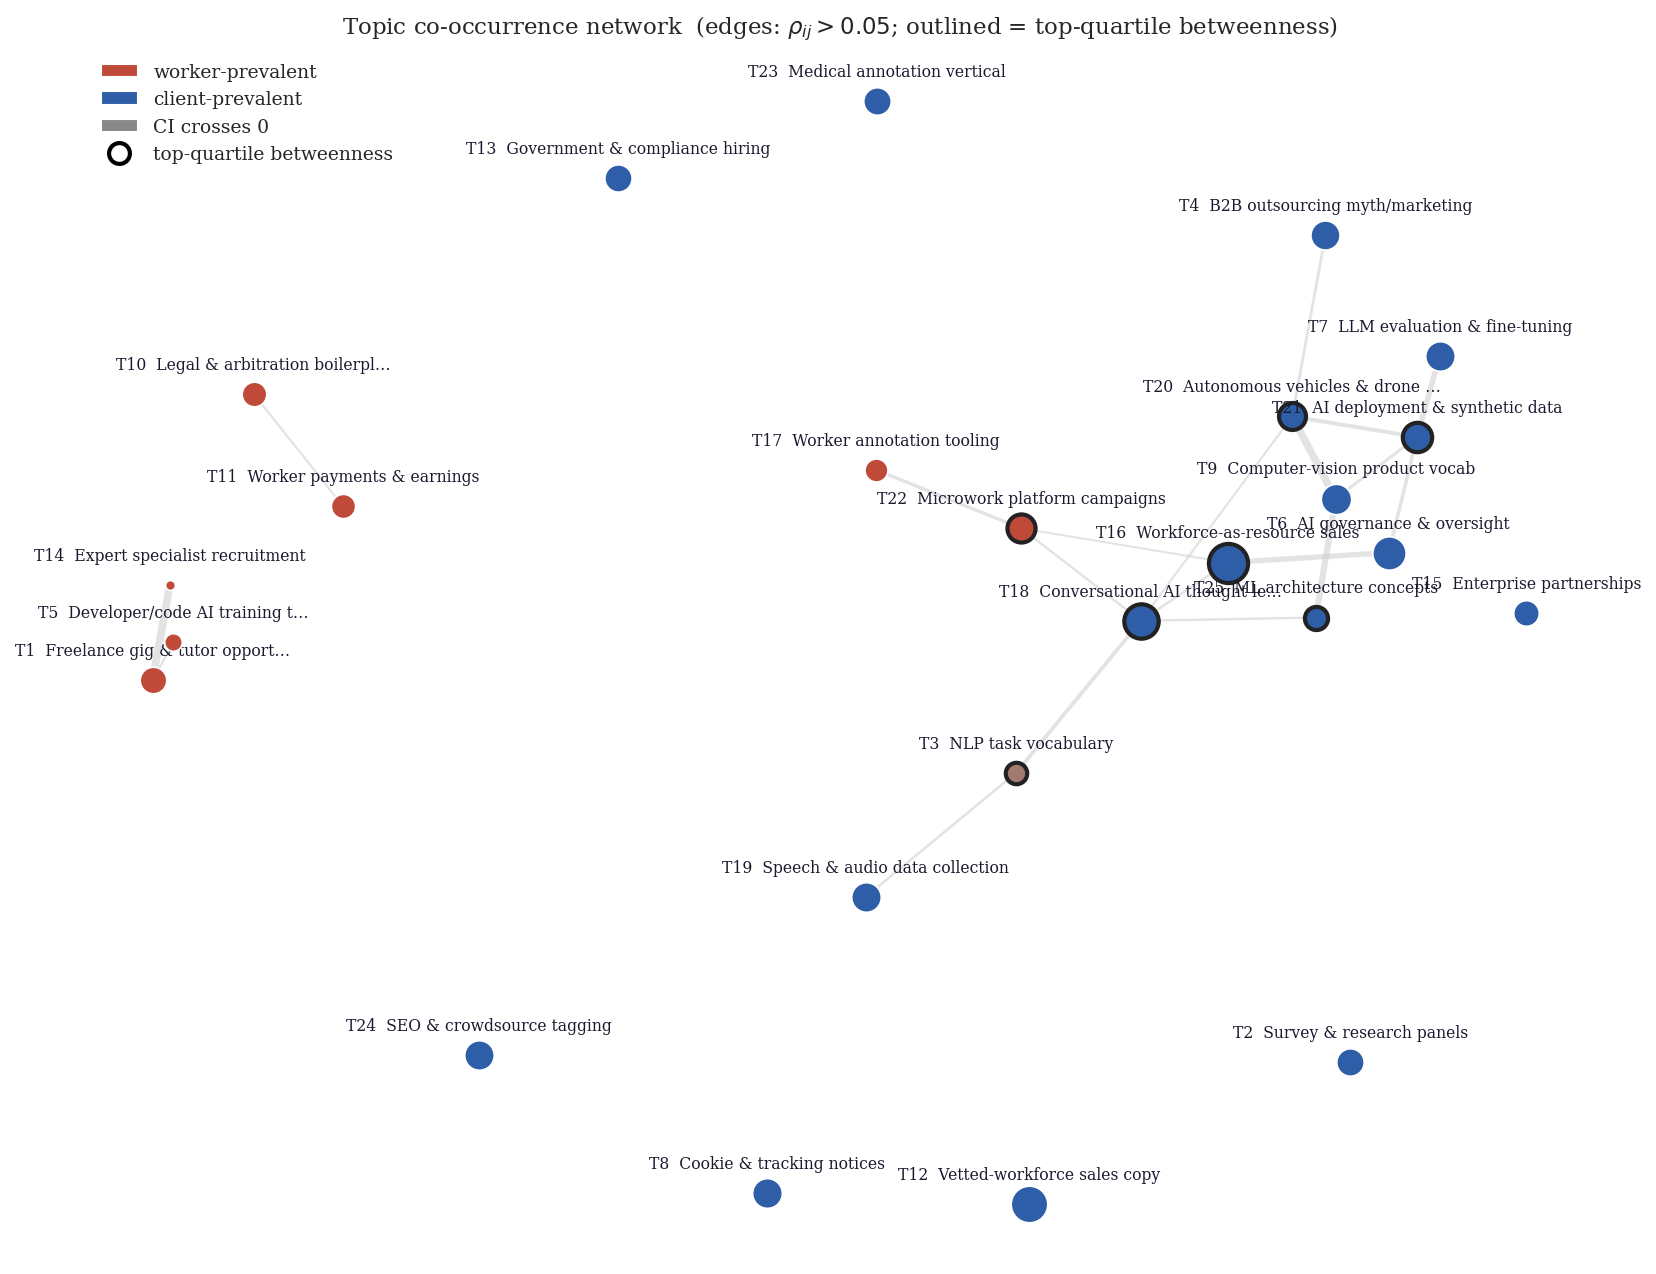

Network: 25 nodes, 19 edges (threshold ρ > 0.05)

Top-quartile betweenness (empirically defined bridging topics):
  T18  Conversational AI thought-leadership        [C]  betw=0.156
  T20  Autonomous vehicles & drone sensing         [C]  betw=0.091
  T21  AI deployment & synthetic data              [C]  betw=0.058
  T 3  NLP task vocabulary                         [S]  betw=0.040
  T22  Microwork platform campaigns                [W]  betw=0.040
  T16  Workforce-as-resource sales                 [C]  betw=0.022
  T25  ML architecture concepts                    [C]  betw=0.022


In [10]:
# =====================================================================
# CELL §4.3.2  —  Figure 4.7: Topic co-occurrence network
# =====================================================================
# Audience-coloured nodes, sized by mean prevalence.
# Bridging topics flagged by top-quartile betweenness centrality
# (a graph-theoretic measure, not hypothesis-dependent).
# Layout seeded by audience direction so the bipartite-like
# structure is legible from positions, not from colours.

import networkx as nx

theta_wide = (pd.read_sql("SELECT page_id, topic_id, theta FROM stm_theta", conn)
                .pivot(index='page_id', columns='topic_id', values='theta'))
corr = theta_wide.corr()

CORR_THRESHOLD = 0.05

G = nx.Graph()
for tid in corr.columns:
    G.add_node(tid)
for i in corr.columns:
    for j in corr.columns:
        if i < j and corr.loc[i, j] > CORR_THRESHOLD:
            G.add_edge(i, j, weight=corr.loc[i, j])

# Betweenness centrality → bridging score
betw = nx.betweenness_centrality(G, weight='weight')
bridging_cutoff = np.quantile(list(betw.values()), 0.75)
bridging = {t: v for t, v in betw.items() if v >= bridging_cutoff}

# Position: spring layout seeded by audience direction
init_pos = {}
for tid in G.nodes:
    row = topic_df[topic_df.topic_id == tid].iloc[0]
    x0 = -1.0 if row['direction'] == 'W' else (1.0 if row['direction'] == 'C' else 0.0)
    y0 = np.random.default_rng(tid).uniform(-1, 1)
    init_pos[tid] = np.array([x0, y0])

pos = nx.spring_layout(G, pos=init_pos, iterations=120,
                       k=0.9, weight='weight', seed=42)

fig, ax = plt.subplots(figsize=(13, 10.5))

for (u, v, d) in G.edges(data=True):
    ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
            color='#CDCDCD', linewidth=d['weight'] * 18, alpha=0.55, zorder=1)

for tid in G.nodes:
    row = topic_df[topic_df.topic_id == tid].iloc[0]
    color = row['colour']
    size = max(row['mean_theta'], 0.005) * 4500
    edge = '#222222' if tid in bridging else 'white'
    lw = 2.0 if tid in bridging else 0.8
    ax.scatter(pos[tid][0], pos[tid][1],
               s=size, c=color, edgecolors=edge, linewidths=lw, zorder=3)
    short = TOPIC_LABELS[tid]
    if len(short) > 30:
        short = short[:28] + '…'
    ax.annotate(f'T{tid}  {short}', pos[tid],
                fontsize=7.5, ha='center', va='bottom',
                xytext=(0, 10), textcoords='offset points', color=C_TEXT)

ax.set_title('Topic co-occurrence network  '
             '(edges: $\\rho_{ij}>0.05$; outlined = top-quartile betweenness)',
             fontsize=11)
ax.axis('off')

legend_elements = [
    mpatches.Patch(facecolor=AUD_WORKER, label='worker-prevalent'),
    mpatches.Patch(facecolor=AUD_CLIENT, label='client-prevalent'),
    mpatches.Patch(facecolor=AUD_SHARED, label='CI crosses 0'),
    plt.Line2D([0], [0], marker='o', color='w', markeredgecolor='black',
               markeredgewidth=2, markersize=10,
               label='top-quartile betweenness'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9, frameon=False)

save_fig(fig, 'fig_47_topic_cooccurrence_network')
plt.show()

print(f'Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges '
      f'(threshold ρ > {CORR_THRESHOLD})')
print('\nTop-quartile betweenness (empirically defined bridging topics):')
for tid, b in sorted(bridging.items(), key=lambda kv: -kv[1]):
    row = topic_df[topic_df.topic_id == tid].iloc[0]
    print(f'  T{tid:>2}  {TOPIC_LABELS[tid]:<42}  '
          f'[{row["direction"]}]  betw={b:.3f}')


  Saved: ../output/chapter4/fig_47_topic_cooccurrence_network.pdf


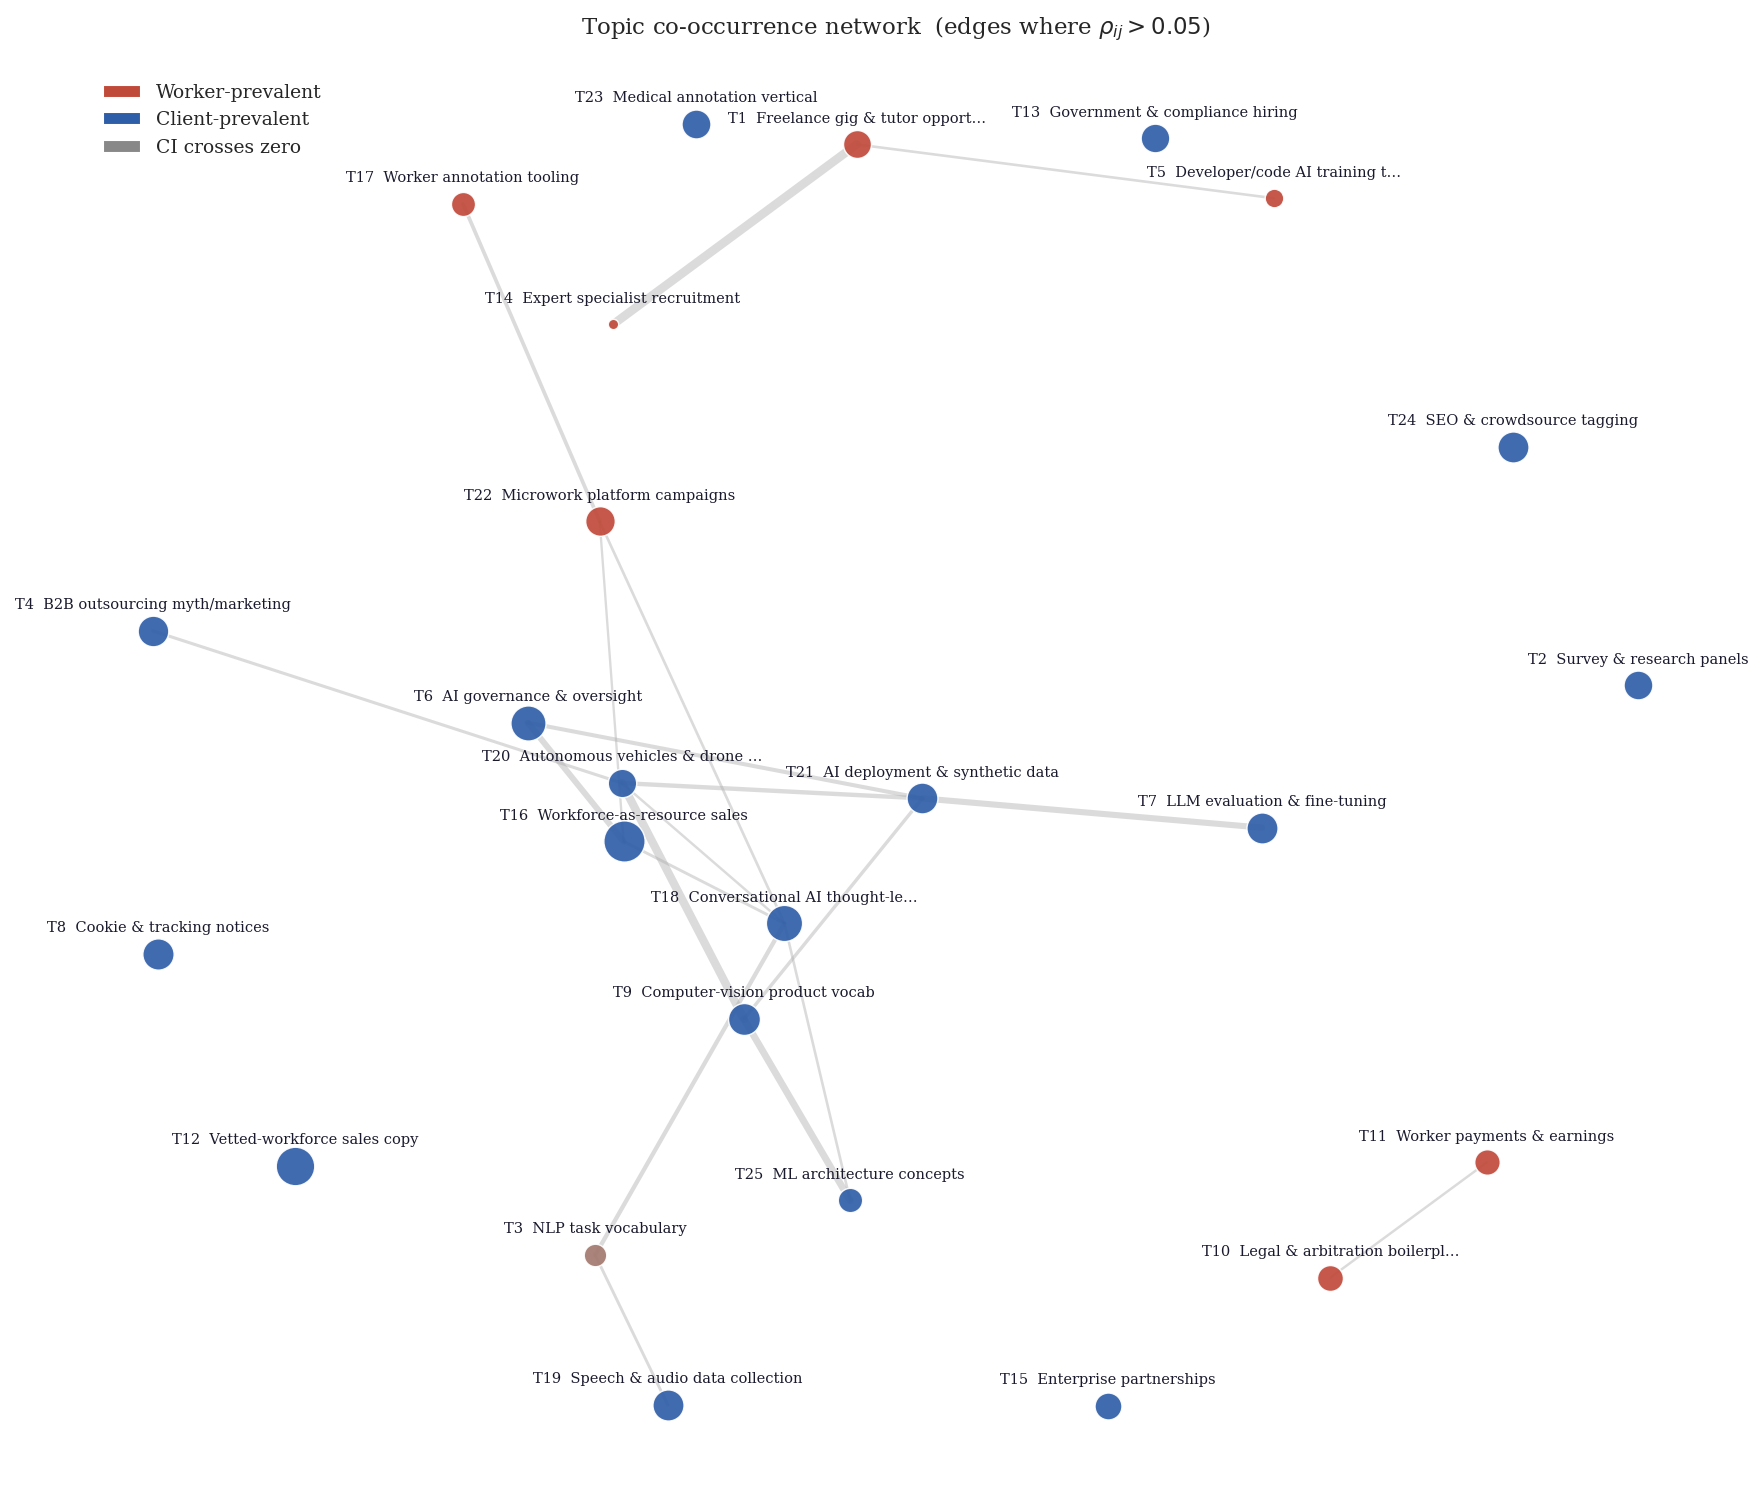

Network: 25 nodes, 19 edges (threshold ρ > 0.05)

Edge composition:
  W–W: 4 edges
  C–C: 11 edges
  W–C: 2 edges
  S–*: 2 edges

All edges (sorted by ρ):
  T 1 [W] — T14 [W]  ρ = 0.208  (Freelance gig & tutor opp  ↔  Expert specialist recruit)
  T 9 [C] — T20 [C]  ρ = 0.198  (Computer-vision product v  ↔  Autonomous vehicles & dro)
  T 9 [C] — T25 [C]  ρ = 0.166  (Computer-vision product v  ↔  ML architecture concepts)
  T 7 [C] — T21 [C]  ρ = 0.146  (LLM evaluation & fine-tun  ↔  AI deployment & synthetic)
  T 6 [C] — T16 [C]  ρ = 0.144  (AI governance & oversight  ↔  Workforce-as-resource sal)
  T20 [C] — T21 [C]  ρ = 0.105  (Autonomous vehicles & dro  ↔  AI deployment & synthetic)
  T 3 [S] — T18 [C]  ρ = 0.103  (NLP task vocabulary  ↔  Conversational AI thought)
  T 6 [C] — T21 [C]  ρ = 0.097  (AI governance & oversight  ↔  AI deployment & synthetic)
  T17 [W] — T22 [W]  ρ = 0.090  (Worker annotation tooling  ↔  Microwork platform campai)
  T 9 [C] — T21 [C]  ρ = 0.081  (Computer-

In [13]:
# =====================================================================
# CELL §4.3.2  —  Figure 4.7: Topic co-occurrence network (v2)
# =====================================================================
# Audience-coloured nodes, sized by mean prevalence.
# Pure spring layout — no audience seeding, so any bipartite-like
# structure is emergent from the co-occurrence data alone.
# Edge width proportional to correlation strength.

import networkx as nx

theta_wide = (pd.read_sql("SELECT page_id, topic_id, theta FROM stm_theta", conn)
                .pivot(index='page_id', columns='topic_id', values='theta'))
corr = theta_wide.corr()

CORR_THRESHOLD = 0.05

G = nx.Graph()
for tid in corr.columns:
    G.add_node(tid)
for i in corr.columns:
    for j in corr.columns:
        if i < j and corr.loc[i, j] > CORR_THRESHOLD:
            G.add_edge(i, j, weight=corr.loc[i, j])

# ── Layout: pure spring, no audience seeding ─────────────────────────
pos = nx.spring_layout(G, k=1.2, iterations=200, weight='weight', seed=42)

# ── Figure ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))

# Edges
for (u, v, d) in G.edges(data=True):
    ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
            color='#B0B0B0', linewidth=d['weight'] * 20,
            alpha=0.45, zorder=1, solid_capstyle='round')

# Nodes
for tid in G.nodes:
    row = topic_df[topic_df.topic_id == tid].iloc[0]
    size = max(row['mean_theta'], 0.005) * 5000
    ax.scatter(pos[tid][0], pos[tid][1],
               s=size, c=row['colour'],
               edgecolors='white', linewidths=0.7, zorder=3, alpha=0.92)

# Labels
for tid in G.nodes:
    short = TOPIC_LABELS[tid]
    if len(short) > 30:
        short = short[:28] + '…'
    ax.annotate(f'T{tid}  {short}', pos[tid],
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 9), textcoords='offset points',
                color=C_TEXT)

ax.set_title('Topic co-occurrence network  '
             '(edges where $\\rho_{ij} > 0.05$)',
             fontsize=11, pad=12)
ax.axis('off')

# Legend
legend_elements = [
    mpatches.Patch(facecolor=AUD_WORKER, label='Worker-prevalent'),
    mpatches.Patch(facecolor=AUD_CLIENT, label='Client-prevalent'),
    mpatches.Patch(facecolor=AUD_SHARED, label='CI crosses zero'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9,
          frameon=False, borderpad=0.8)

plt.tight_layout()
save_fig(fig, 'fig_47_topic_cooccurrence_network')
plt.show()

# ── Diagnostics ──────────────────────────────────────────────────────
print(f'Network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges '
      f'(threshold ρ > {CORR_THRESHOLD})')

# Classify edges by audience pairing
edge_types = {'W–W': [], 'C–C': [], 'W–C': [], 'S–*': []}
for u, v, d in G.edges(data=True):
    du = topic_df[topic_df.topic_id == u].iloc[0]['direction']
    dv = topic_df[topic_df.topic_id == v].iloc[0]['direction']
    pair = tuple(sorted([du, dv]))
    rho = d['weight']
    if 'S' in pair:
        edge_types['S–*'].append((u, v, rho))
    elif pair == ('W', 'W'):
        edge_types['W–W'].append((u, v, rho))
    elif pair == ('C', 'C'):
        edge_types['C–C'].append((u, v, rho))
    else:
        edge_types['W–C'].append((u, v, rho))

print('\nEdge composition:')
for label, edges in edge_types.items():
    if edges:
        print(f'  {label}: {len(edges)} edges')

print('\nAll edges (sorted by ρ):')
all_edges = [(u, v, d['weight']) for u, v, d in G.edges(data=True)]
all_edges.sort(key=lambda x: -x[2])
for u, v, rho in all_edges:
    du = topic_df[topic_df.topic_id == u].iloc[0]['direction']
    dv = topic_df[topic_df.topic_id == v].iloc[0]['direction']
    print(f'  T{u:>2} [{du}] — T{v:>2} [{dv}]  ρ = {rho:.3f}  '
          f'({TOPIC_LABELS[u][:25]}  ↔  {TOPIC_LABELS[v][:25]})')

# Isolated nodes (no edges above threshold)
isolated = [n for n in G.nodes if G.degree(n) == 0]
if isolated:
    print(f'\nIsolated topics ({len(isolated)}):')
    for tid in sorted(isolated):
        row = topic_df[topic_df.topic_id == tid].iloc[0]
        print(f'  T{tid:>2} [{row["direction"]}]  {TOPIC_LABELS[tid]}')


---
## §4.4 — Interpretive Synthesis: H1a–H1c with Close Reading

This section does not produce new figures but **selects and re-presents** evidence from §4.2–4.3, supplemented by close reading passages.  
The cells below extract the specific numbers and passages needed.

  Saved: ../output/chapter4/fig_48_stm_hypothesis_summary.pdf


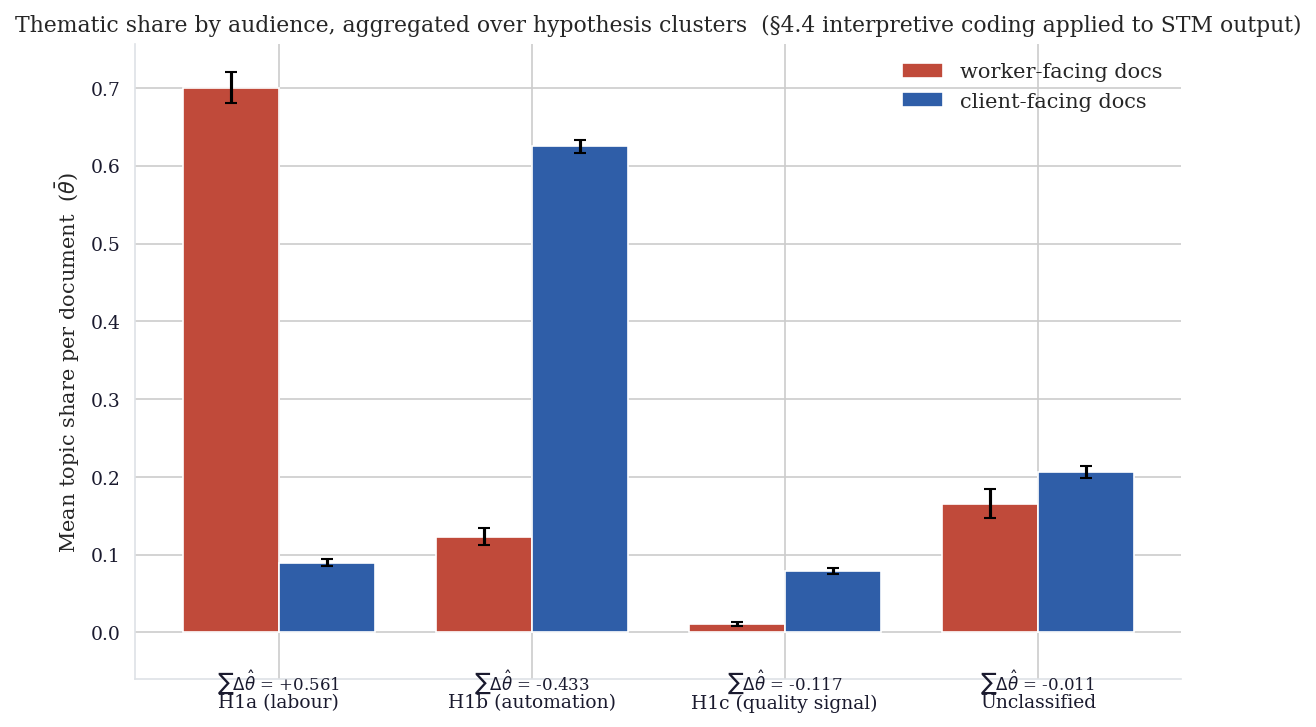

             cluster audience  mean_theta      sem  n_docs  delta_sum
        H1a (labour)   worker    0.700447 0.010286     813   0.560596
        H1a (labour)   client    0.089701 0.002282    4994   0.560596
    H1b (automation)   worker    0.123244 0.005344     813  -0.433017
    H1b (automation)   client    0.624933 0.004340    4994  -0.433017
H1c (quality signal)   worker    0.010542 0.001280     813  -0.116760
H1c (quality signal)   client    0.078995 0.001887    4994  -0.116760
        Unclassified   worker    0.165767 0.009537     813  -0.010928
        Unclassified   client    0.206370 0.004175    4994  -0.010928


In [41]:
# =====================================================================
# CELL §4.4.0  —  Figure 4.8: Hypothesis-aggregated cluster summary
# =====================================================================
# *Step-2 figure.*  Belongs to §4.4 because aggregating topics by
# hypothesis is itself an interpretive coding move.  Place this cell
# at the start of the §4.4 section, AFTER the prose that introduces
# and justifies the topic→hypothesis coding.

clusters = {
    'H1a (labour)':         [tid for tid, h in TOPIC_HYPOTHESIS.items() if h == 'H1a'],
    'H1b (automation)':     [tid for tid, h in TOPIC_HYPOTHESIS.items() if h == 'H1b'],
    'H1c (quality signal)': [tid for tid, h in TOPIC_HYPOTHESIS.items() if h == 'H1c'],
    'Unclassified':         [tid for tid, h in TOPIC_HYPOTHESIS.items() if h is None],
}

rows = []
for name, tids in clusters.items():
    per_doc = pd.read_sql(f"""
        SELECT pt.audience, t.page_id, SUM(t.theta) AS theta_sum
        FROM   stm_theta    AS t
        JOIN   pages_tfidf  AS pt ON pt.page_id = t.page_id
        WHERE  t.topic_id IN ({','.join(str(x) for x in tids)})
          AND  pt.audience IN ('worker', 'client')
        GROUP BY pt.audience, t.page_id
    """, conn)
    delta_sum = topic_df.loc[topic_df['topic_id'].isin(tids), 'estimate'].sum()
    for aud in ['worker', 'client']:
        s = per_doc.loc[per_doc['audience'] == aud, 'theta_sum']
        rows.append({
            'cluster':    name,
            'audience':   aud,
            'mean_theta': s.mean(),
            'sem':        s.std(ddof=1) / np.sqrt(len(s)),
            'n_docs':     len(s),
            'delta_sum':  delta_sum,
        })
summary = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 5.5))
cluster_names = list(clusters.keys())
x = np.arange(len(cluster_names))
bar_w = 0.38

w_vals = summary.loc[summary.audience == 'worker'].set_index('cluster').loc[cluster_names]
c_vals = summary.loc[summary.audience == 'client'].set_index('cluster').loc[cluster_names]

ax.bar(x - bar_w/2, w_vals['mean_theta'], bar_w,
       yerr=1.96 * w_vals['sem'],
       color=AUD_WORKER, edgecolor='white', label='worker-facing docs',
       capsize=3, linewidth=0.8)
ax.bar(x + bar_w/2, c_vals['mean_theta'], bar_w,
       yerr=1.96 * c_vals['sem'],
       color=AUD_CLIENT, edgecolor='white', label='client-facing docs',
       capsize=3, linewidth=0.8)

for xi, cname in enumerate(cluster_names):
    d = w_vals.loc[cname, 'delta_sum']
    ax.text(xi, -0.045,
            f'$\\sum\\Delta\\hat\\theta$ = {d:+.3f}',
            ha='center', va='top', fontsize=8, color=C_TEXT)

ax.set_xticks(x)
ax.set_xticklabels(cluster_names, fontsize=10)
ax.set_ylabel('Mean topic share per document  ($\\bar{\\theta}$)', fontsize=10)
ax.set_title('Thematic share by audience, aggregated over hypothesis clusters  '
             '(§4.4 interpretive coding applied to STM output)',
             fontsize=10.5)
ax.legend(loc='upper right', frameon=False)
ax.set_ylim(bottom=-0.06)
apply_style(ax)
save_fig(fig, 'fig_48_stm_hypothesis_summary')
plt.show()

print(summary.to_string(index=False))

In [82]:
# ============================================================
# CELL 1 — Imports and configuration
# ============================================================

import sqlite3
import json
import math
import textwrap
import warnings
from pathlib import Path
from datetime import datetime
from collections import defaultdict

import pandas as pd
import numpy as np

warnings.filterwarnings("ignore")

# ── Project paths ────────────────────────────────────────────
DB_PATH    = Path("../data/scraping_2.db")
OUTPUT_DIR = Path("../output/step_2_sampling")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Hypothesis → STM topic mapping ──────────────────────────
# Derived from Table 4.3 in the thesis (direction = C / W, significant).
# Only topics whose 95% CI excludes zero are listed.
HYPOTHESIS_TOPICS = {
    "H1a": {
        "worker_topics": [11, 1],           # T11 payments+earnings, T1 gig listings
        "client_topics": [16, 12],          # T16 workforce-as-resource, T12 vetted-workforce
        "description":   "Labour visibility gap",
    },
    "H1b": {
        "worker_topics": [5],               # T5 developer/code AI training tasks
        "client_topics": [25, 7, 21],       # T25 ML arch, T7 LLM eval, T21 AI deployment
        "description":   "Automation myth",
    },
    "H1c": {
        "worker_topics": [],                # No strong worker-side topic for H1c
        "client_topics": [12, 6, 16],       # T12 vetted-workforce, T6 governance, T16 workforce
        "description":   "Strategic hypervisibility",
    },
}

# ── Focal terms per hypothesis (from keyness + co-occurrence analysis) ──
FOCAL_TERMS = {
    "H1a": {
        "worker": ["apply", "payment", "earn", "worker", "job"],
        "client": ["workforce", "resource", "supplier", "crowdsourced"],
    },
    "H1b": {
        "worker": ["task", "complete", "submit", "guideline"],
        "client": ["autonomous", "annotation", "automate", "algorithm", "label"],
    },
    "H1c": {
        "worker": [],           # H1c is primarily a client-side phenomenon
        "client": ["human", "vetted", "irreplaceable", "judgement", "oversight"],
    },
}

# ── Within-company pairs ─────────────────────────────────────
# (company_id, client_domain, worker_domain, split_level)
# split_level: "domain" = separate scraped domains
#              "url"    = same domain, audience split via page_audience_override
COMPANY_PAIRS = [
    ("appen",    "appen.com",      "crowdgen.com",      "domain"),
    ("toloka",   "toloka.ai",      "mindrift.ai",       "domain"),
    ("centific", "centific.com",   "oneforma.com",      "domain"),
    ("labelbox", "labelbox.com",   "alignerr.com",      "domain"),
    ("scale",    "scale.com",      "remotasks.com",     "domain"),
    ("clickworker", "clickworker.com", "clickworker.com", "url"),
    ("prolific", "prolific.com",   "prolific.com",      "url"),
    ("opentrain","opentrain.ai",   "opentrain.ai",      "url"),
]

# ── Sampling parameters ──────────────────────────────────────
TOP_THETA_PER_TOPIC   = 3    # top-θ docs per (topic × audience) for Stratum 2
TOP_KEYNESS_PAGES     = 2    # pages per focal term for Stratum 3
MIN_DOMAIN_SUPPORT    = 3    # minimum distinct platforms a term must appear on
SAMPLE_TARGET_MIN     = 40
SAMPLE_TARGET_MAX     = 60

print("✓  Configuration loaded.")
print(f"   Database : {DB_PATH.resolve()}")
print(f"   Output   : {OUTPUT_DIR.resolve()}")



✓  Configuration loaded.
   Database : /Users/yannickkayser/Uni/Master/Master_Thesis/DarkSideofAI/data/scraping_2.db
   Output   : /Users/yannickkayser/Uni/Master/Master_Thesis/DarkSideofAI/output/step_2_sampling


In [83]:
# ============================================================
# CELL 2 — Database connection and prerequisite checks
# ============================================================

def open_db(path: Path) -> sqlite3.Connection:
    """Open DB with row_factory and verify required tables exist."""
    if not path.exists():
        raise FileNotFoundError(
            f"Database not found: {path}\n"
            "Run from the project root directory."
        )
    conn = sqlite3.connect(path)
    conn.row_factory = sqlite3.Row
    conn.execute("PRAGMA journal_mode=WAL")

    required = [
        "corpus_view", "keyness_results",
        "platform_term_counts", "cooccurrence_results",
        "stm_theta", "stm_prevalence",
    ]
    optional = ["page_audience_override", "stm_topic_terms"]

    existing = {
        r[0] for r in conn.execute(
            "SELECT name FROM sqlite_master WHERE type IN ('table','view')"
        ).fetchall()
    }

    missing_required = [t for t in required if t not in existing]
    if missing_required:
        conn.close()
        raise RuntimeError(
            f"Missing required tables: {missing_required}\n"
            "Ensure the full pipeline has been run before Step 2 sampling."
        )

    missing_optional = [t for t in optional if t not in existing]
    if missing_optional:
        print(f"⚠  Optional tables absent (URL-split pairs will be skipped): "
              f"{missing_optional}")

    print("✓  Database connection established.")
    print(f"   Required tables present: {required}")
    return conn


conn = open_db(DB_PATH)


✓  Database connection established.
   Required tables present: ['corpus_view', 'keyness_results', 'platform_term_counts', 'cooccurrence_results', 'stm_theta', 'stm_prevalence']


In [85]:
# ============================================================
# CELL 3 — Initialise / reset the step2_sample table
# ============================================================

def init_step2_sample_table(conn: sqlite3.Connection) -> None:
    """
    Create (or reset) the step2_sample table.

    Columns:
      page_id          — FK to pages.id
      url              — denormalised for convenience
      domain           — platform domain
      audience         — 'client' | 'worker'
      company_id       — links within-company pairs
      stratum          — 1 | 2 | 3
      hypothesis       — 'H1a' | 'H1b' | 'H1c'
      topic_id         — STM topic ID (NULL for Stratum 3)
      theta            — topic proportion (NULL for Stratum 3)
      focal_term       — term driving selection (NULL for Stratum 1/2)
      rel_freq         — relative term frequency (NULL for Stratum 1/2)
      sampling_reason  — human-readable provenance string
      priority_rank    — rank within stratum-hypothesis-audience group
    """
    conn.executescript("""
        DROP TABLE IF EXISTS step2_sample;

        CREATE TABLE step2_sample (
            id              INTEGER PRIMARY KEY AUTOINCREMENT,
            page_id         INTEGER NOT NULL,
            url             TEXT,
            domain          TEXT,
            audience        TEXT    CHECK(audience IN ('client','worker')),
            company_id      TEXT,
            stratum         INTEGER CHECK(stratum IN (1,2,3)),
            hypothesis      TEXT,
            topic_id        INTEGER,
            theta           REAL,
            focal_term      TEXT,
            rel_freq        REAL,
            sampling_reason TEXT,
            priority_rank   INTEGER,
            created_at      TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
            UNIQUE(page_id, hypothesis, stratum)
        );

        CREATE INDEX IF NOT EXISTS idx_s2_stratum    ON step2_sample(stratum);
        CREATE INDEX IF NOT EXISTS idx_s2_hypothesis ON step2_sample(hypothesis);
        CREATE INDEX IF NOT EXISTS idx_s2_audience   ON step2_sample(audience);
    """)
    conn.commit()
    print("✓  step2_sample table initialised (fresh run).")


init_step2_sample_table(conn)


✓  step2_sample table initialised (fresh run).


In [86]:
# ============================================================
# CELL 4 — Helper: insert rows with deduplication
# ============================================================

def insert_sample_rows(
    conn: sqlite3.Connection,
    rows: list[dict],
    verbose: bool = True,
) -> int:
    """
    Insert sampling rows into step2_sample, skipping duplicates.

    A duplicate is defined as (page_id, hypothesis, stratum) already present.
    Returns the number of newly inserted rows.
    """
    inserted = 0
    for row in rows:
        try:
            conn.execute("""
                INSERT INTO step2_sample
                    (page_id, url, domain, audience, company_id,
                     stratum, hypothesis, topic_id, theta,
                     focal_term, rel_freq, sampling_reason, priority_rank)
                VALUES
                    (:page_id, :url, :domain, :audience, :company_id,
                     :stratum, :hypothesis, :topic_id, :theta,
                     :focal_term, :rel_freq, :sampling_reason, :priority_rank)
            """, row)
            inserted += 1
        except sqlite3.IntegrityError:
            pass   # already present — skip silently

    conn.commit()
    if verbose:
        print(f"   → {inserted} rows inserted ({len(rows) - inserted} skipped as duplicates)")
    return inserted


In [87]:
# ============================================================
# CELL 4b — Boilerplate page filter
# ============================================================
#
# Pages dominated by cookie notices, privacy policies, legal
# boilerplate, navigation menus, and tracking scripts are
# analytically useless for close reading because their
# vocabulary reflects web-compliance genre conventions rather
# than platform discourse about labour.
#
# The filter combines four signals:
#
#   1. STM topic T8 (Cookie & tracking notices, Δθ̂ = −0.035)
#      Pages whose *dominant* topic is T8 are structurally
#      boilerplate regardless of any other vocabulary signal.
#
#   2. URL path heuristics: paths whose last segment matches
#      known boilerplate directories (privacy, cookie, legal,
#      terms, imprint, sitemap, etc.).
#
#   3. Vocabulary saturation: pages where >30% of unique lemmas
#      are in the curated boilerplate term list (drawn from the
#      excluded_terms table plus a small hardcoded supplement).
#
#   4. Token-count floor: very short pages (token_count < 80)
#      are almost always navigational stubs or error pages.
#
# The function returns a frozenset of page_ids to exclude and
# also prints a diagnostic breakdown so you can audit the
# filter before running the strata.
# ────────────────────────────────────────────────────────────

import re

# ── Boilerplate URL path patterns ────────────────────────────
# Match on the *path* component only (after the domain).
# Patterns are applied case-insensitively as substring matches.
BOILERPLATE_PATH_PATTERNS = [
    "privacy",
    "cookie",
    "legal",
    "/terms",
    "imprint",
    "sitemap",
    "disclaimer",
    "accessibility",
    "data-protection",
    "datenschutz",       # German GDPR page
    "gdpr",
    "ccpa",
    "opt-out",
    "robots",
    "/404",
    "/500",
    "unsubscribe",
    "copyright",
]

# ── Hardcoded boilerplate vocabulary supplement ───────────────
# Terms that reliably mark compliance/legal pages but may not
# be in excluded_terms (which targets analytical noise rather
# than page-type classification).
BOILERPLATE_VOCAB_SUPPLEMENT = {
    "cookie", "gdpr", "ccpa", "consent", "opt-out", "opt-in",
    "privacy", "policy", "cookies", "analytics", "tracker",
    "tracking", "pixel", "beacon", "session", "expire",
    "duration", "advertisement", "advertiser", "third-party",
    "imprint", "disclaimer", "liability", "jurisdiction",
    "arbitration", "clause", "processor", "controller",
    "subprocessor", "dpa", "scc", "sccs", "eea",
    "copyright", "trademark", "intellectual", "proprietary",
    "sitemap", "robots", "crawl", "index", "noindex",
}

# ── STM topic IDs that are structurally boilerplate ──────────
# T8  = Cookie & tracking notices  (Δθ̂ = −0.035, client-prevalent)
# T10 = Legal & arbitration boilerplate (Δθ̂ = +0.092, worker-prevalent)
# Both are legitimate analytical findings in Step 1 but are
# uninformative for close reading of *labour discourse*.
BOILERPLATE_STM_TOPICS = {8, 10}

# ── Minimum token count ───────────────────────────────────────
MIN_TOKEN_COUNT = 80

# ── Vocabulary saturation threshold ──────────────────────────
# If this fraction of a page's unique lemmas are boilerplate
# terms, the page is considered boilerplate-dominated.
BOILERPLATE_VOCAB_SATURATION = 0.30


def build_boilerplate_exclusion_set(
    conn: sqlite3.Connection,
    verbose: bool = True,
) -> frozenset:
    """
    Identify and return a frozenset of page_ids to exclude from
    Step 2 sampling on boilerplate grounds.

    The four signals are applied as a union: a page is excluded
    if it triggers *any* of the four criteria.  This is
    deliberately conservative — it is better to exclude a
    borderline page from the close-reading sample than to include
    a cookie banner in your qualitative analysis.

    Returns
    -------
    frozenset of int
        Page IDs to pass as exclude_page_ids to stratum functions.
    """

    excluded = {}   # page_id → reason string

    # ── Signal 1: STM dominant topic ─────────────────────────
    # Check whether stm_theta is available (it may not be if
    # 03b_import_stm.py has not been run yet).
    has_stm = conn.execute(
        "SELECT name FROM sqlite_master WHERE name='stm_theta'"
    ).fetchone() is not None

    if has_stm:
        topic_placeholder = ",".join(str(t) for t in BOILERPLATE_STM_TOPICS)
        rows = conn.execute(f"""
            SELECT DISTINCT page_id
            FROM   stm_theta
            WHERE  dominant_topic IN ({topic_placeholder})
        """).fetchall()
        for r in rows:
            excluded.setdefault(r[0], "stm_dominant_topic")
        if verbose:
            print(f"  Signal 1 (STM dominant topic ∈ {BOILERPLATE_STM_TOPICS}): "
                  f"{len(rows)} pages")
    else:
        if verbose:
            print("  Signal 1 (STM): stm_theta not found — skipped.")

    # ── Signal 2: URL path heuristics ────────────────────────
    url_rows = conn.execute("""
        SELECT id, url FROM pages WHERE url IS NOT NULL
    """).fetchall()

    url_hits = 0
    for r in url_rows:
        url_lower = (r["url"] or "").lower()
        # Extract path component (everything after the domain)
        path_match = re.search(r"https?://[^/]+(/.*)$", url_lower)
        path = path_match.group(1) if path_match else url_lower
        for pattern in BOILERPLATE_PATH_PATTERNS:
            if pattern in path:
                if r["id"] not in excluded:
                    excluded[r["id"]] = f"url_path:{pattern}"
                    url_hits += 1
                break
    if verbose:
        print(f"  Signal 2 (URL path patterns):             {url_hits} pages")

    # ── Signal 3: Vocabulary saturation ──────────────────────
    # Load the excluded_terms table if available for the full
    # boilerplate vocab, then supplement with hardcoded list.
    boilerplate_vocab = set(BOILERPLATE_VOCAB_SUPPLEMENT)

    try:
        et_rows = conn.execute("SELECT term FROM excluded_terms").fetchall()
        boilerplate_vocab.update(r["term"] for r in et_rows)
    except Exception:
        pass   # excluded_terms may be malformed (schema note)

    tfidf_rows = conn.execute("""
        SELECT page_id, unigrams, token_count
        FROM   pages_tfidf
        WHERE  token_count >= :min_tc
          AND  unigrams IS NOT NULL
    """, {"min_tc": MIN_TOKEN_COUNT}).fetchall()

    vocab_hits = 0
    for r in tfidf_rows:
        if r["page_id"] in excluded:
            continue
        try:
            tokens = json.loads(r["unigrams"])
        except (json.JSONDecodeError, TypeError):
            continue
        unique_lemmas = set(tokens)
        if not unique_lemmas:
            continue
        overlap = unique_lemmas & boilerplate_vocab
        saturation = len(overlap) / len(unique_lemmas)
        if saturation >= BOILERPLATE_VOCAB_SATURATION:
            excluded[r["page_id"]] = (
                f"vocab_saturation:{saturation:.2f}"
                f" ({len(overlap)}/{len(unique_lemmas)} lemmas)"
            )
            vocab_hits += 1
    if verbose:
        print(f"  Signal 3 (vocab saturation ≥{BOILERPLATE_VOCAB_SATURATION:.0%}): "
              f"{vocab_hits} pages")

    # ── Signal 4: Token-count floor ──────────────────────────
    short_rows = conn.execute("""
        SELECT page_id FROM pages_tfidf
        WHERE  token_count < :min_tc
    """, {"min_tc": MIN_TOKEN_COUNT}).fetchall()

    short_hits = 0
    for r in short_rows:
        if r["page_id"] not in excluded:
            excluded[r["page_id"]] = f"token_count<{MIN_TOKEN_COUNT}"
            short_hits += 1
    if verbose:
        print(f"  Signal 4 (token_count < {MIN_TOKEN_COUNT}):                "
              f"{short_hits} pages")

    # ── Summary ───────────────────────────────────────────────
    total = len(excluded)
    if verbose:
        print(f"\n  Total boilerplate pages excluded: {total}")

        # Breakdown by reason type
        reason_counts = {}
        for reason in excluded.values():
            key = reason.split(":")[0]
            reason_counts[key] = reason_counts.get(key, 0) + 1
        for reason, count in sorted(reason_counts.items(),
                                    key=lambda x: -x[1]):
            print(f"    {reason:<35} {count:>5} pages")

        # Audience breakdown of excluded pages
        exc_ids_str = ",".join(str(i) for i in excluded) or "0"
        aud_rows = conn.execute(f"""
            SELECT cv.audience, COUNT(*) AS n
            FROM   corpus_view cv
            WHERE  cv.page_id IN ({exc_ids_str})
            GROUP  BY cv.audience
        """).fetchall()
        print("\n  Excluded pages by audience:")
        for row in aud_rows:
            print(f"    {row['audience']:<12} {row['n']:>5}")

    return frozenset(excluded.keys())


# Run the filter — call this ONCE and pass the result to all strata
print("Building boilerplate exclusion set...")
BOILERPLATE_IDS = build_boilerplate_exclusion_set(conn, verbose=True)
print(f"\n✓  BOILERPLATE_IDS contains {len(BOILERPLATE_IDS)} page_ids.")
print("   Pass this as the base exclude_page_ids in Cells 5, 6, and 7.")

Building boilerplate exclusion set...
  Signal 1 (STM dominant topic ∈ {8, 10}): 596 pages
  Signal 2 (URL path patterns):             185 pages
  Signal 3 (vocab saturation ≥30%): 0 pages
  Signal 4 (token_count < 80):                710 pages

  Total boilerplate pages excluded: 1491
    token_count<80                        710 pages
    stm_dominant_topic                    596 pages
    url_path                              185 pages

  Excluded pages by audience:
    client        1184
    worker         176

✓  BOILERPLATE_IDS contains 1491 page_ids.
   Pass this as the base exclude_page_ids in Cells 5, 6, and 7.


In [88]:
# ============================================================
# CELL 5 — STRATUM 1: Within-company pair pages
# ============================================================
#
# Rationale: Within-company pairs provide the strongest possible
# evidence for audience-register differentiation because they control
# for company-level variation in style, vocabulary, and market niche.
# Audience differences that persist across the within-company control
# are attributable to register rather than to between-company factors
# (King, Keohane & Verba, 1994; Newlands, 2021).
#
# Selection logic:
#   For each pair × hypothesis combination, select the top-θ client page
#   and top-θ worker page on the most hypothesis-relevant STM topic.
#   This ensures both pages in a matched unit share the same thematic
#   domain, isolating register as the explanatory variable.
# ────────────────────────────────────────────────────────────

def get_stm_top_pages_for_domain(
    conn: sqlite3.Connection,
    domain: str,
    audience: str,
    topic_ids: list[int],
    top_n: int = 2,
    exclude_page_ids: set | None = None,
    use_override: bool = False,
) -> list[dict]:
    """
    Return top-N pages (by θ) for the given domain, audience, and topic list.

    For URL-split pairs (use_override=True) the audience label is taken from
    page_audience_override rather than from platforms, because both client and
    worker pages share the same domain.
    """
    if exclude_page_ids is None:
        exclude_page_ids = set()

    results = []

    for topic_id in topic_ids:
        if use_override:
            # URL-split: audience determined by page_audience_override
            query = """
                SELECT
                    th.page_id,
                    cv.url,
                    cv.domain,
                    o.audience,
                    th.topic_id,
                    th.theta,
                    cv.company_id
                FROM stm_theta th
                JOIN corpus_view cv ON cv.page_id = th.page_id
                JOIN page_audience_override o ON o.page_id = th.page_id
                WHERE cv.domain    = :domain
                  AND o.audience   = :audience
                  AND th.topic_id  = :topic_id
                ORDER BY th.theta DESC
                LIMIT :top_n
            """
        else:
            # Domain-split: audience from corpus_view / platforms
            query = """
                SELECT
                    th.page_id,
                    cv.url,
                    cv.domain,
                    cv.audience,
                    th.topic_id,
                    th.theta,
                    cv.company_id
                FROM stm_theta th
                JOIN corpus_view cv ON cv.page_id = th.page_id
                WHERE cv.domain   = :domain
                  AND cv.audience = :audience
                  AND th.topic_id = :topic_id
                ORDER BY th.theta DESC
                LIMIT :top_n
            """

        rows = conn.execute(query, {
            "domain": domain, "audience": audience,
            "topic_id": topic_id, "top_n": top_n,
        }).fetchall()

        for rank, r in enumerate(rows, start=1):
            if r["page_id"] in exclude_page_ids:
                continue
            results.append({
                "page_id":         r["page_id"],
                "url":             r["url"],
                "domain":          r["domain"],
                "audience":        r["audience"],
                "company_id":      r["company_id"] or domain.split(".")[0],
                "stratum":         1,
                "hypothesis":      None,   # filled by caller
                "topic_id":        r["topic_id"],
                "theta":           r["theta"],
                "focal_term":      None,
                "rel_freq":        None,
                "sampling_reason": (
                    f"Stratum 1 — within-company pair | "
                    f"domain={r['domain']} audience={r['audience']} "
                    f"topic_id={r['topic_id']} theta={r['theta']:.4f}"
                ),
                "priority_rank":   rank,
            })

    return results


def run_stratum1(conn: sqlite3.Connection) -> int:
    """
    Populate Stratum 1: within-company pair pages.

    For each of the 8 pairs × 3 hypotheses × {client, worker}:
      — identify the most hypothesis-relevant topic(s)
      — select top-θ page(s) from the relevant domain × audience
      — mark with stratum=1 and the hypothesis label
    """
    print("\n" + "="*60)
    print("STRATUM 1 — Within-company pair pages")
    print("="*60)

    total_inserted = 0

    for company_id, client_domain, worker_domain, split_level in COMPANY_PAIRS:
        use_override = (split_level == "url")

        # Check whether page_audience_override exists for URL-split pairs
        if use_override:
            override_exists = conn.execute(
                "SELECT name FROM sqlite_master WHERE name='page_audience_override'"
            ).fetchone()
            if not override_exists:
                print(f"  ⚠  Skipping {company_id} (URL-split) — "
                      "page_audience_override table not found.")
                continue

        print(f"\n  Company: {company_id}  [{split_level}-level split]")

        for hyp, config in HYPOTHESIS_TOPICS.items():
            all_topics = config["client_topics"] + config["worker_topics"]
            if not all_topics:
                continue

            # Already-inserted page IDs to avoid within-pair duplication
            existing_ids = {
                r[0] for r in conn.execute(
                    "SELECT page_id FROM step2_sample"
                ).fetchall()
            }

            # Client side
            client_rows = get_stm_top_pages_for_domain(
                conn,
                domain       = client_domain,
                audience     = "client",
                topic_ids    = config["client_topics"] or all_topics,
                top_n        = 2,
                exclude_page_ids = existing_ids,
                use_override = use_override,
            )
            for row in client_rows:
                row["hypothesis"] = hyp
                row["sampling_reason"] = (
                    row["sampling_reason"] +
                    f" | company={company_id} hyp={hyp}"
                )

            # Worker side
            worker_rows = get_stm_top_pages_for_domain(
                conn,
                domain       = worker_domain,
                audience     = "worker",
                topic_ids    = config["worker_topics"] or all_topics,
                top_n        = 2,
                exclude_page_ids = existing_ids,
                use_override = use_override,
            )
            for row in worker_rows:
                row["hypothesis"] = hyp
                row["sampling_reason"] = (
                    row["sampling_reason"] +
                    f" | company={company_id} hyp={hyp}"
                )

            all_rows = client_rows + worker_rows
            n = insert_sample_rows(conn, all_rows, verbose=False)
            if n:
                print(f"    {hyp}: +{n} pages "
                      f"({len(client_rows)} client, {len(worker_rows)} worker)")
            total_inserted += n

    print(f"\n  Stratum 1 total: {total_inserted} pages inserted.")
    return total_inserted


s1_count = run_stratum1(conn)



STRATUM 1 — Within-company pair pages

  Company: appen  [domain-level split]
    H1a: +4 pages (0 client, 4 worker)
    H1b: +2 pages (0 client, 2 worker)
    H1c: +6 pages (0 client, 6 worker)

  Company: toloka  [domain-level split]
    H1a: +8 pages (4 client, 4 worker)
    H1b: +8 pages (6 client, 2 worker)
    H1c: +11 pages (6 client, 6 worker)

  Company: centific  [domain-level split]

  Company: labelbox  [domain-level split]
    H1a: +4 pages (4 client, 0 worker)
    H1b: +5 pages (6 client, 0 worker)
    H1c: +6 pages (6 client, 0 worker)

  Company: scale  [domain-level split]
    H1a: +4 pages (4 client, 0 worker)
    H1b: +6 pages (6 client, 0 worker)
    H1c: +6 pages (6 client, 0 worker)

  Company: clickworker  [url-level split]

  Company: prolific  [url-level split]

  Company: opentrain  [url-level split]

  Stratum 1 total: 70 pages inserted.


In [89]:
# ============================================================
# CELL 6 — STRATUM 2: STM-guided documents
# ============================================================
#
# Rationale: The STM posterior probability ranking (the findThoughts
# criterion in Roberts et al., 2019) identifies the documents that
# most purely instantiate each topic's vocabulary. Nelson (2020, p.18)
# recommends using the model's own output to guide document selection
# for Step 2: the highest-θ documents are the "closest to" the
# discovered thematic pattern and therefore most productive for
# understanding what that pattern does communicatively.
#
# Cross-platform coverage is enforced: each hypothesis-cluster must
# draw pages from at least MIN_DOMAIN_SUPPORT distinct platforms to
# prevent findings from resting on a single platform's idiosyncrasies.
# ────────────────────────────────────────────────────────────

def run_stratum2(conn: sqlite3.Connection) -> int:
    """
    Populate Stratum 2: STM-guided documents (top-θ per topic × audience).

    For each hypothesis × topic × audience triplet:
      1. Query stm_theta for pages not already in step2_sample.
      2. Select TOP_THETA_PER_TOPIC pages with the highest θ.
      3. Insert with stratum=2.
    """
    print("\n" + "="*60)
    print("STRATUM 2 — STM-guided documents (top-θ per topic × audience)")
    print("="*60)

    total_inserted = 0

    for hyp, config in HYPOTHESIS_TOPICS.items():
        print(f"\n  Hypothesis: {hyp} — {config['description']}")

        for audience, topic_ids in [
            ("client", config["client_topics"]),
            ("worker", config["worker_topics"]),
        ]:
            if not topic_ids:
                continue

            for topic_id in topic_ids:
                # Exclude pages already in the sample
                existing_ids_str = ",".join(
                    str(r[0]) for r in conn.execute(
                        "SELECT page_id FROM step2_sample"
                    ).fetchall()
                ) or "0"

                rows = conn.execute(f"""
                    SELECT
                        th.page_id,
                        cv.url,
                        cv.domain,
                        cv.audience,
                        cv.company_id,
                        th.topic_id,
                        th.theta
                    FROM stm_theta th
                    JOIN corpus_view cv ON cv.page_id = th.page_id
                    WHERE th.topic_id  = :topic_id
                      AND cv.audience  = :audience
                      AND th.page_id NOT IN ({existing_ids_str})
                    ORDER BY th.theta DESC
                    LIMIT :top_n
                """, {
                    "topic_id": topic_id,
                    "audience": audience,
                    "top_n":    TOP_THETA_PER_TOPIC,
                }).fetchall()

                sample_rows = []
                for rank, r in enumerate(rows, start=1):
                    sample_rows.append({
                        "page_id":         r["page_id"],
                        "url":             r["url"],
                        "domain":          r["domain"],
                        "audience":        r["audience"],
                        "company_id":      r["company_id"],
                        "stratum":         2,
                        "hypothesis":      hyp,
                        "topic_id":        r["topic_id"],
                        "theta":           r["theta"],
                        "focal_term":      None,
                        "rel_freq":        None,
                        "sampling_reason": (
                            f"Stratum 2 — STM top-θ | "
                            f"hyp={hyp} topic_id={topic_id} "
                            f"audience={audience} theta={r['theta']:.4f} "
                            f"rank={rank}"
                        ),
                        "priority_rank":   rank,
                    })

                n = insert_sample_rows(conn, sample_rows, verbose=False)
                if n:
                    print(f"    T{topic_id:02d} ({audience}): +{n} pages")
                total_inserted += n

    # ── Domain coverage audit for Stratum 2 ─────────────────
    print("\n  Domain coverage check (Stratum 2 pages):")
    coverage = conn.execute("""
        SELECT hypothesis, audience, COUNT(DISTINCT domain) AS n_domains,
               COUNT(*) AS n_pages
        FROM   step2_sample
        WHERE  stratum = 2
        GROUP  BY hypothesis, audience
        ORDER  BY hypothesis, audience
    """).fetchall()
    for row in coverage:
        flag = "⚠ " if row["n_domains"] < MIN_DOMAIN_SUPPORT else "✓ "
        print(f"    {flag} {row['hypothesis']} / {row['audience']}: "
              f"{row['n_pages']} pages from {row['n_domains']} domains")

    print(f"\n  Stratum 2 total: {total_inserted} pages inserted.")
    return total_inserted


s2_count = run_stratum2(conn)



STRATUM 2 — STM-guided documents (top-θ per topic × audience)

  Hypothesis: H1a — Labour visibility gap
    T16 (client): +3 pages
    T12 (client): +3 pages
    T11 (worker): +3 pages
    T01 (worker): +3 pages

  Hypothesis: H1b — Automation myth
    T25 (client): +3 pages
    T07 (client): +3 pages
    T21 (client): +3 pages
    T05 (worker): +3 pages

  Hypothesis: H1c — Strategic hypervisibility
    T12 (client): +3 pages
    T06 (client): +3 pages
    T16 (client): +3 pages

  Domain coverage check (Stratum 2 pages):
    ✓  H1a / client: 6 pages from 3 domains
    ⚠  H1a / worker: 6 pages from 2 domains
    ✓  H1b / client: 9 pages from 5 domains
    ⚠  H1b / worker: 3 pages from 1 domains
    ✓  H1c / client: 9 pages from 3 domains

  Stratum 2 total: 33 pages inserted.


In [90]:
# ============================================================
# CELL 7 — STRATUM 3: Keyness-extreme documents  (CORRECTED)
# ============================================================
#
# platform_term_counts is domain-level, not page-level — it has no
# page_id column.  Page-level term frequency is computed here by
# counting occurrences of the focal term in pages_tfidf.unigrams
# (the JSON lemma list) and normalising by token_count.
#
# The cross-platform support check uses platform_term_counts
# correctly: it still tells us whether a term appears on ≥3
# distinct platforms, which is a domain-level question.
# ────────────────────────────────────────────────────────────

def check_cross_platform_support(
    conn: sqlite3.Connection,
    term: str,
    audience: str,
    min_domains: int = MIN_DOMAIN_SUPPORT,
) -> bool:
    """
    Return True if the term appears on >= min_domains platforms
    for the given audience.  Uses platform_term_counts (domain-level).
    """
    row = conn.execute("""
        SELECT COUNT(DISTINCT ptc.domain) AS n
        FROM   platform_term_counts ptc
        JOIN   platforms pl ON pl.domain = ptc.domain
        WHERE  ptc.term     = :term
          AND  pl.audience  = :audience
          AND  ptc.freq     > 0
    """, {"term": term, "audience": audience}).fetchone()
    return (row["n"] if row else 0) >= min_domains


def get_top_pages_by_term_frequency(
    conn: sqlite3.Connection,
    term: str,
    audience: str,
    top_n: int = TOP_KEYNESS_PAGES,
    exclude_page_ids: set | None = None,
) -> list[dict]:
    """
    Find the top-N pages with the highest relative frequency of `term`,
    computing page-level rel_freq as:

        count(term in unigrams) / token_count

    Pages are drawn from pages_tfidf joined to corpus_view for
    audience and domain metadata.  Audience is matched via
    corpus_view (which handles the page_audience_override join).
    """
    if exclude_page_ids is None:
        exclude_page_ids = set()

    # Pull all pages for this audience with their token lists.
    # We filter in Python because JSON_EACH / LIKE on large token
    # lists is slow and SQLite's JSON support varies by version.
    rows = conn.execute("""
        SELECT
            cv.page_id,
            p.url,
            cv.domain,
            cv.audience,
            cv.company_id,
            pt.unigrams,
            pt.token_count
        FROM   corpus_view cv
        JOIN   pages_tfidf pt ON pt.page_id = cv.page_id
        JOIN   pages       p  ON p.id       = cv.page_id
        WHERE  cv.audience   = :audience
          AND  pt.token_count > 0
          AND  pt.unigrams IS NOT NULL
    """, {"audience": audience}).fetchall()

    scored = []
    for r in rows:
        if r["page_id"] in exclude_page_ids:
            continue
        try:
            tokens = json.loads(r["unigrams"])
        except (json.JSONDecodeError, TypeError):
            continue
        count = tokens.count(term)
        if count == 0:
            continue
        rel_freq = count / r["token_count"]
        scored.append({
            "page_id":    r["page_id"],
            "url":        r["url"],
            "domain":     r["domain"],
            "audience":   r["audience"],
            "company_id": r["company_id"],
            "rel_freq":   rel_freq,
            "term_count": count,
        })

    # Sort descending by rel_freq, take top_n
    scored.sort(key=lambda x: x["rel_freq"], reverse=True)
    return scored[:top_n]


def run_stratum3(conn: sqlite3.Connection) -> int:
    """
    Populate Stratum 3: lexically extreme documents.

    For each focal term:
      1. Check cross-platform support via platform_term_counts.
      2. Compute page-level rel_freq from pages_tfidf.unigrams.
      3. Select top TOP_KEYNESS_PAGES pages not already in sample.
      4. Insert with stratum=3.
    """
    print("\n" + "="*60)
    print("STRATUM 3 — Keyness-extreme documents (highest page-level rel_freq)")
    print("="*60)

    total_inserted = 0

    for hyp, term_dict in FOCAL_TERMS.items():
        print(f"\n  Hypothesis: {hyp}")

        for audience, terms in term_dict.items():
            if not terms:
                continue

            for term in terms:
                # Domain-level support check (platform_term_counts is correct here)
                if not check_cross_platform_support(conn, term, audience):
                    print(f"    ⚠  '{term}' ({audience}): skipped "
                          f"— fewer than {MIN_DOMAIN_SUPPORT} platforms")
                    continue

                # Existing page IDs to exclude
                existing_ids = {
                    r[0] for r in conn.execute(
                        "SELECT page_id FROM step2_sample"
                    ).fetchall()
                }

                # Page-level frequency ranking
                top_pages = get_top_pages_by_term_frequency(
                    conn, term, audience,
                    top_n=TOP_KEYNESS_PAGES,
                    exclude_page_ids=existing_ids,
                )

                if not top_pages:
                    print(f"    ⚠  '{term}' ({audience}): no pages found")
                    continue

                sample_rows = []
                for rank, r in enumerate(top_pages, start=1):
                    sample_rows.append({
                        "page_id":         r["page_id"],
                        "url":             r["url"],
                        "domain":          r["domain"],
                        "audience":        r["audience"],
                        "company_id":      r["company_id"],
                        "stratum":         3,
                        "hypothesis":      hyp,
                        "topic_id":        None,
                        "theta":           None,
                        "focal_term":      term,
                        "rel_freq":        r["rel_freq"],
                        "sampling_reason": (
                            f"Stratum 3 — keyness extreme | "
                            f"hyp={hyp} term={term} "
                            f"audience={audience} "
                            f"rel_freq={r['rel_freq']:.6f} "
                            f"term_count={r['term_count']} "
                            f"rank={rank}"
                        ),
                        "priority_rank":   rank,
                    })

                n = insert_sample_rows(conn, sample_rows, verbose=False)
                if n:
                    print(f"    '{term}' ({audience}): +{n} pages  "
                          f"(top rel_freq={top_pages[0]['rel_freq']:.4f})")
                total_inserted += n

    print(f"\n  Stratum 3 total: {total_inserted} pages inserted.")
    return total_inserted


s3_count = run_stratum3(conn)



STRATUM 3 — Keyness-extreme documents (highest page-level rel_freq)

  Hypothesis: H1a
    'apply' (worker): +2 pages  (top rel_freq=0.1118)
    'payment' (worker): +2 pages  (top rel_freq=0.2000)
    'earn' (worker): +2 pages  (top rel_freq=0.0667)
    'worker' (worker): +2 pages  (top rel_freq=0.0498)
    'job' (worker): +2 pages  (top rel_freq=0.0591)
    'workforce' (client): +2 pages  (top rel_freq=0.0549)
    'resource' (client): +2 pages  (top rel_freq=0.0714)
    'supplier' (client): +2 pages  (top rel_freq=0.0417)
    'crowdsourced' (client): +2 pages  (top rel_freq=0.0136)

  Hypothesis: H1b
    'task' (worker): +2 pages  (top rel_freq=0.0625)
    'complete' (worker): +2 pages  (top rel_freq=0.0240)
    'submit' (worker): +2 pages  (top rel_freq=0.0606)
    'guideline' (worker): +2 pages  (top rel_freq=0.0198)
    'autonomous' (client): +2 pages  (top rel_freq=0.1250)
    'annotation' (client): +2 pages  (top rel_freq=0.1667)
    'automate' (client): +2 pages  (top rel_freq=

In [91]:
# ============================================================
# CELL 8 — Coverage audit
# ============================================================
#
# Three criteria must be satisfied (from the sampling strategy document):
#   A — ≥8 pages per hypothesis, ≥3 per audience
#   B — ≥3 distinct platforms per hypothesis-cluster
#   C — all 8 within-company pairs represented
# ────────────────────────────────────────────────────────────

def run_coverage_audit(conn: sqlite3.Connection) -> pd.DataFrame:
    print("\n" + "="*60)
    print("COVERAGE AUDIT")
    print("="*60)

    # ── Overall counts ───────────────────────────────────────
    total = conn.execute("SELECT COUNT(*) FROM step2_sample").fetchone()[0]
    print(f"\n  Total pages in sample: {total}")
    if total < SAMPLE_TARGET_MIN:
        print(f"  ⚠  Below minimum target ({SAMPLE_TARGET_MIN}). "
              "Consider relaxing TOP_THETA_PER_TOPIC or TOP_KEYNESS_PAGES.")
    elif total > SAMPLE_TARGET_MAX:
        print(f"  ⚠  Above maximum target ({SAMPLE_TARGET_MAX}). "
              "Consider trimming lower-priority pages.")
    else:
        print(f"  ✓  Within target range ({SAMPLE_TARGET_MIN}–{SAMPLE_TARGET_MAX}).")

    # ── Criterion A: pages per hypothesis × audience ─────────
    print("\n  Criterion A — pages per hypothesis × audience:")
    crit_a = conn.execute("""
        SELECT hypothesis, audience,
               COUNT(*)             AS n_pages,
               COUNT(DISTINCT domain) AS n_domains
        FROM   step2_sample
        GROUP  BY hypothesis, audience
        ORDER  BY hypothesis, audience
    """).fetchall()

    rows_a = []
    for row in crit_a:
        flag = "✓" if row["n_pages"] >= 3 else "⚠"
        rows_a.append({
            "Hypothesis": row["hypothesis"],
            "Audience":   row["audience"],
            "Pages":      row["n_pages"],
            "Domains":    row["n_domains"],
            "Criterion A": f"{flag} (≥3 required)",
        })
        print(f"    {flag}  {row['hypothesis']} / {row['audience']}: "
              f"{row['n_pages']} pages, {row['n_domains']} domains")

    # ── Criterion B: distinct platforms per hypothesis ───────
    print("\n  Criterion B — distinct platforms per hypothesis:")
    crit_b = conn.execute("""
        SELECT hypothesis, COUNT(DISTINCT domain) AS n_domains, COUNT(*) AS n_pages
        FROM   step2_sample
        GROUP  BY hypothesis
        ORDER  BY hypothesis
    """).fetchall()

    for row in crit_b:
        flag = "✓" if row["n_domains"] >= MIN_DOMAIN_SUPPORT else "⚠"
        print(f"    {flag}  {row['hypothesis']}: {row['n_pages']} pages "
              f"from {row['n_domains']} platforms "
              f"(min={MIN_DOMAIN_SUPPORT})")

    # ── Criterion C: within-company pair representation ──────
    print("\n  Criterion C — within-company pair representation:")
    pair_company_ids = {p[0] for p in COMPANY_PAIRS}
    sampled_companies = {
        r[0] for r in conn.execute(
            "SELECT DISTINCT company_id FROM step2_sample WHERE stratum = 1"
        ).fetchall()
    }
    for cid in sorted(pair_company_ids):
        flag = "✓" if cid in sampled_companies else "⚠  MISSING"
        print(f"    {flag}  {cid}")

    # ── Stratum breakdown ────────────────────────────────────
    print("\n  Stratum breakdown:")
    strata = conn.execute("""
        SELECT stratum, COUNT(*) AS n FROM step2_sample GROUP BY stratum
    """).fetchall()
    for row in strata:
        label = {1: "Within-company pairs",
                 2: "STM-guided",
                 3: "Keyness-extreme"}.get(row["stratum"], "?")
        print(f"    Stratum {row['stratum']} ({label}): {row['n']} pages")

    # ── Return full sample as DataFrame ─────────────────────
    df = pd.read_sql("""
        SELECT id, page_id, url, domain, audience, company_id,
               stratum, hypothesis, topic_id, theta,
               focal_term, rel_freq, sampling_reason, priority_rank
        FROM   step2_sample
        ORDER  BY stratum, hypothesis, audience, priority_rank
    """, conn)

    return df


sample_df = run_coverage_audit(conn)
print(f"\n  sample_df shape: {sample_df.shape}")
sample_df.head(10)



COVERAGE AUDIT

  Total pages in sample: 145
  ⚠  Above maximum target (60). Consider trimming lower-priority pages.

  Criterion A — pages per hypothesis × audience:
    ✓  H1a / client: 26 pages, 9 domains
    ✓  H1a / worker: 24 pages, 5 domains
    ✓  H1b / client: 36 pages, 8 domains
    ✓  H1b / worker: 15 pages, 7 domains
    ✓  H1c / client: 33 pages, 10 domains
    ✓  H1c / worker: 11 pages, 2 domains

  Criterion B — distinct platforms per hypothesis:
    ✓  H1a: 50 pages from 14 platforms (min=3)
    ✓  H1b: 51 pages from 15 platforms (min=3)
    ✓  H1c: 44 pages from 12 platforms (min=3)

  Criterion C — within-company pair representation:
    ✓  appen
    ⚠  MISSING  centific
    ⚠  MISSING  clickworker
    ✓  labelbox
    ⚠  MISSING  opentrain
    ⚠  MISSING  prolific
    ✓  scale
    ✓  toloka

  Stratum breakdown:
    Stratum 1 (Within-company pairs): 70 pages
    Stratum 2 (STM-guided): 33 pages
    Stratum 3 (Keyness-extreme): 42 pages

  sample_df shape: (145, 14)


,id,page_id,url,domain,audience,company_id,stratum,hypothesis,topic_id,theta,focal_term,rel_freq,sampling_reason,priority_rank
0,13,1193,https://toloka.ai/events/paris-retail-week,toloka.ai,client,toloka,1,H1a,16.0,0.331010,None,NaN,Stratum 1 — within-company pair | domain=toloka.ai audience=client topic_id=16 theta=0.3310 | company=toloka hyp=H1a,1
1,15,1317,https://toloka.ai/legal/special_terms,toloka.ai,client,toloka,1,H1a,12.0,0.041838,None,NaN,Stratum 1 — within-company pair | domain=toloka.ai audience=client topic_id=12 theta=0.0418 | company=toloka hyp=H1a,1
2,40,9802,https://labelbox.com/compare/scale-alternative/,labelbox.com,client,labelbox,1,H1a,16.0,0.539087,None,NaN,Stratum 1 — within-company pair | domain=labelbox.com audience=client topic_id=16 theta=0.5391 | company=labelbox hyp=H1a,1
3,42,9808,https://labelbox.com/compare/cvat-alternative/,labelbox.com,client,labelbox,1,H1a,12.0,0.118602,None,NaN,Stratum 1 — within-company pair | domain=labelbox.com audience=client topic_id=12 theta=0.1186 | company=labelbox hyp=H1a,1
4,55,6599,https://scale.com/blog/nick-beighton-asos-transforming-ecommerce,scale.com,client,scale,1,H1a,16.0,0.462747,None,NaN,Stratum 1 — within-company pair | domain=scale.com audience=client topic_id=16 theta=0.4627 | company=scale hyp=H1a,1
5,57,7048,https://scale.com/docs/rapid-faq,scale.com,client,scale,1,H1a,12.0,0.207385,None,NaN,Stratum 1 — within-company pair | domain=scale.com audience=client topic_id=12 theta=0.2074 | company=scale hyp=H1a,1
6,14,1166,https://toloka.ai/events/ecommerce-expo-uk,toloka.ai,client,toloka,1,H1a,16.0,0.265339,None,NaN,Stratum 1 — within-company pair | domain=toloka.ai audience=client topic_id=16 theta=0.2653 | company=toloka hyp=H1a,2
7,16,1275,https://toloka.ai/tolokers,toloka.ai,client,toloka,1,H1a,12.0,0.040477,None,NaN,Stratum 1 — within-company pair | domain=toloka.ai audience=client topic_id=12 theta=0.0405 | company=toloka hyp=H1a,2
8,41,9812,https://labelbox.com/compare/appen-alternative/,labelbox.com,client,labelbox,1,H1a,16.0,0.489841,None,NaN,Stratum 1 — within-company pair | domain=labelbox.com audience=client topic_id=16 theta=0.4898 | company=labelbox hyp=H1a,2
9,43,9811,https://labelbox.com/compare/amazon-sagemaker-alternative/,labelbox.com,client,labelbox,1,H1a,12.0,0.104194,None,NaN,Stratum 1 — within-company pair | domain=labelbox.com audience=client topic_id=12 theta=0.1042 | company=labelbox hyp=H1a,2


In [92]:
# ============================================================
# CELL 9 — Supplementary selection: fill gaps from coverage audit
# ============================================================
#
# If Criterion C reveals missing within-company pairs, or Criterion B
# reveals under-represented platforms, this cell performs a targeted
# supplementary selection using the next-ranked STM candidates.
# ────────────────────────────────────────────────────────────

def fill_missing_pairs(conn: sqlite3.Connection) -> int:
    """
    For any within-company pair not yet in step2_sample (Stratum 1),
    add the highest-θ page from each side using any hypothesis-relevant topic.
    This is the Criterion C correction step.
    """
    print("\n  Criterion C supplementary fill:")

    sampled_companies = {
        r[0] for r in conn.execute(
            "SELECT DISTINCT company_id FROM step2_sample WHERE stratum = 1"
        ).fetchall()
    }

    total_inserted = 0

    for company_id, client_domain, worker_domain, split_level in COMPANY_PAIRS:
        if company_id in sampled_companies:
            continue

        use_override = (split_level == "url")
        print(f"    Filling missing pair: {company_id}")

        # Use H1a (largest prevalence effect) as fallback topic pool
        all_relevant_topics = (
            HYPOTHESIS_TOPICS["H1a"]["client_topics"] +
            HYPOTHESIS_TOPICS["H1a"]["worker_topics"]
        )

        existing_ids = {
            r[0] for r in conn.execute("SELECT page_id FROM step2_sample").fetchall()
        }

        for audience, domain in [("client", client_domain), ("worker", worker_domain)]:
            rows = get_stm_top_pages_for_domain(
                conn, domain, audience,
                topic_ids=all_relevant_topics,
                top_n=1,
                exclude_page_ids=existing_ids,
                use_override=use_override,
            )
            for row in rows:
                row["hypothesis"] = "H1a"
                row["sampling_reason"] += f" | SUPPLEMENTARY fill for {company_id}"
            n = insert_sample_rows(conn, rows, verbose=False)
            total_inserted += n
            if n:
                print(f"      + {n} {audience} page(s) from {domain}")

    if total_inserted == 0:
        print("    All pairs already represented — no supplementary fill needed.")

    return total_inserted


fill_count = fill_missing_pairs(conn)
print(f"\n  Supplementary fill: {fill_count} pages added.")



  Criterion C supplementary fill:
    Filling missing pair: centific
    Filling missing pair: clickworker
    Filling missing pair: prolific
    Filling missing pair: opentrain
    All pairs already represented — no supplementary fill needed.

  Supplementary fill: 0 pages added.


In [93]:
# ============================================================
# CELL 10 — KWIC extraction utility
# ============================================================
#
# This cell provides the KWIC extraction function used in the
# close reading procedure (Section 3.3.1 of the thesis).
# Window = ±15 tokens (consistent with the co-occurrence analysis
# window used in Step 1).
# ────────────────────────────────────────────────────────────

KWIC_WINDOW = 15   # tokens either side of the keyword (matches Step 1)


def get_page_tokens(conn: sqlite3.Connection, page_id: int) -> list[str]:
    """Load lemmatised unigram list for a page from pages_tfidf."""
    row = conn.execute(
        "SELECT unigrams FROM pages_tfidf WHERE page_id = :pid",
        {"pid": page_id}
    ).fetchone()
    if row is None:
        return []
    return json.loads(row["unigrams"])


def get_page_segments(conn: sqlite3.Connection, page_id: int) -> list[list[str]]:
    """Load sentence-segmented tokens for a page."""
    row = conn.execute(
        "SELECT segments FROM pages_tfidf WHERE page_id = :pid",
        {"pid": page_id}
    ).fetchone()
    if row is None:
        return []
    raw = row["segments"]
    if not raw:
        return []
    segs = json.loads(raw)
    # segments may be list[str] (flat) or list[list[str]] (nested)
    if segs and isinstance(segs[0], list):
        return segs
    # Fallback: treat the whole unigram list as one segment
    tokens = get_page_tokens(conn, page_id)
    return [tokens]


def kwic_lines(
    segments: list[list[str]],
    target: str,
    window: int = KWIC_WINDOW,
    max_hits: int = 6,
) -> list[str]:
    """
    Extract KWIC lines for `target` from sentence-segmented tokens.

    The window is applied strictly within each sentence (segment) to
    prevent cross-sentence co-occurrences — consistent with the
    sentence-scoped window used in 02_step1_analysis.py.

    Returns a list of formatted strings:
      "...left context [TARGET] right context..."
    """
    hits = []
    for seg in segments:
        for i, tok in enumerate(seg):
            if tok == target:
                left  = seg[max(0, i - window):i]
                right = seg[i + 1:i + 1 + window]
                line  = (
                    "..." +
                    " ".join(left) +
                    f" [[[{target.upper()}]]] " +
                    " ".join(right) +
                    "..."
                )
                hits.append(line)
                if len(hits) >= max_hits:
                    return hits
    return hits


def extract_kwic_for_sample(
    conn: sqlite3.Connection,
    focal_terms: list[str],
    hypothesis: str | None = None,
    audience: str | None = None,
    max_pages: int = 20,
) -> pd.DataFrame:
    """
    Run KWIC extraction for all pages in step2_sample matching the filters.

    Returns a DataFrame with one row per KWIC hit:
      page_id, url, domain, audience, hypothesis, stratum,
      focal_term, kwic_line, segment_context
    """
    query = "SELECT * FROM step2_sample WHERE 1=1"
    params = {}
    if hypothesis:
        query += " AND hypothesis = :hyp"
        params["hyp"] = hypothesis
    if audience:
        query += " AND audience = :aud"
        params["aud"] = audience
    query += f" ORDER BY stratum, priority_rank LIMIT {max_pages}"

    pages = conn.execute(query, params).fetchall()

    records = []
    for page in pages:
        segments = get_page_segments(conn, page["page_id"])
        if not segments:
            continue
        for term in focal_terms:
            hits = kwic_lines(segments, term)
            for hit in hits:
                records.append({
                    "page_id":   page["page_id"],
                    "url":       page["url"],
                    "domain":    page["domain"],
                    "audience":  page["audience"],
                    "hypothesis":page["hypothesis"],
                    "stratum":   page["stratum"],
                    "focal_term":term,
                    "kwic_line": hit,
                })

    return pd.DataFrame(records)


# Quick demonstration for H1a worker-side terms
print("KWIC extraction — H1a worker register (demonstration):")
kwic_demo = extract_kwic_for_sample(
    conn,
    focal_terms=["worker", "apply", "payment"],
    hypothesis="H1a",
    audience="worker",
    max_pages=10,
)
print(kwic_demo[["domain", "focal_term", "kwic_line"]].head(10).to_string(index=False))


KWIC extraction — H1a worker register (demonstration):
      domain focal_term                                                                                                                                                                                          kwic_line
crowdgen.com      apply                                                                                                              ... [[[APPLY]]] monetize expertise philosophy expertise philosophy highly valuable...
crowdgen.com      apply ...solve complex philosophical problem familiarity ai ml model plus join project aristotle start earn remotely [[[APPLY]]] project aristotle philosophy prompt generation annotation specialist...
crowdgen.com      apply                                                                                                                                               ... [[[APPLY]]] frequently ask question faq legit...
crowdgen.com      apply                                              

In [94]:
# ============================================================
# CELL 11 — Per-page interpretive note template generator
# ============================================================
#
# Generates a structured markdown template for each selected page
# that can be filled in during close reading.
# The three interpretive criteria (Nelson Step 2) are:
#   - Invisibilisation  → H1a
#   - Substitution      → H1b
#   - Renarration       → H1c
# ────────────────────────────────────────────────────────────

CRITERIA_QUESTIONS = {
    "H1a": [
        "Does the text avoid naming the workers who produce the output?",
        "What agent occupies the subject position of production-related verbs?",
        "Are workers replaced by process-denoting nominals (annotation, labeling, dataset)?",
    ],
    "H1b": [
        "Does automation vocabulary appear where labour vocabulary would be expected?",
        "Is human involvement syntactically absent from product claims?",
        "What verbs frame the AI output — active (produces, delivers) or passive/agentless?",
    ],
    "H1c": [
        "Is human involvement foregrounded as a quality attribute rather than a labour relation?",
        "Does 'human' collocate with evaluative adjectives (irreplaceable, expert, vetted)?",
        "Is labour invoked to justify a price premium rather than to describe a worker's activity?",
    ],
}


def generate_reading_templates(
    conn: sqlite3.Connection,
    output_dir: Path,
    hypothesis: str | None = None,
) -> None:
    """
    Write one markdown file per selected page containing:
      - Page metadata (URL, domain, audience, STM topic)
      - KWIC lines for the focal terms
      - Structured interpretive note template
    """
    query = """
        SELECT s.*, p.text_content
        FROM   step2_sample s
        JOIN   pages p ON p.id = s.page_id
        WHERE  1=1
    """
    params = {}
    if hypothesis:
        query += " AND s.hypothesis = :hyp"
        params["hyp"] = hypothesis
    query += " ORDER BY s.stratum, s.hypothesis, s.priority_rank"

    pages = conn.execute(query, params).fetchall()

    for page in pages:
        hyp        = page["hypothesis"] or "general"
        aud        = page["audience"]
        domain     = page["domain"] or "unknown"
        safe_domain = domain.replace(".", "_")
        filename   = (
            f"s{page['stratum']}_{hyp}_{aud}_{safe_domain}"
            f"_p{page['page_id']}.md"
        )
        out_path = output_dir / filename

        # Determine focal terms for KWIC
        terms = (
            FOCAL_TERMS.get(hyp, {}).get(aud, []) or
            (["worker", "human"] if aud == "worker" else ["human", "annotation"])
        )

        segments = get_page_segments(conn, page["page_id"])
        kwic_all = {}
        for term in terms:
            hits = kwic_lines(segments, term, max_hits=4)
            if hits:
                kwic_all[term] = hits

        # Write markdown template
        lines = []
        lines.append(f"# Close reading: {hyp} | {aud} | {domain}")
        lines.append("")
        lines.append("## Metadata")
        lines.append(f"- **page_id**: {page['page_id']}")
        lines.append(f"- **url**: {page['url']}")
        lines.append(f"- **domain**: {domain}")
        lines.append(f"- **audience**: {aud}")
        lines.append(f"- **hypothesis**: {hyp}")
        lines.append(f"- **stratum**: {page['stratum']}")
        if page["topic_id"] is not None:
            lines.append(f"- **stm_topic**: T{page['topic_id']:02d}  "
                         f"(θ = {page['theta']:.4f})")
        if page["focal_term"]:
            lines.append(f"- **focal_term**: {page['focal_term']}  "
                         f"(rel_freq = {page['rel_freq']:.4f})")
        lines.append(f"- **sampling_reason**: {page['sampling_reason']}")
        lines.append("")

        # KWIC section
        lines.append("## KWIC lines")
        if kwic_all:
            for term, hits in kwic_all.items():
                lines.append(f"\n### `{term}`")
                for hit in hits:
                    lines.append(f"> {hit}")
        else:
            lines.append("_(no focal-term hits in tokenised text)_")
        lines.append("")

        # Interpretive template
        questions = CRITERIA_QUESTIONS.get(hyp, [])
        lines.append("## Interpretive note")
        lines.append("")
        for q in questions:
            lines.append(f"**{q}**")
            lines.append("")
            lines.append("_[Your answer here]_")
            lines.append("")
        lines.append("---")
        lines.append("### Representative KWIC line for thesis (≤15 words)")
        lines.append("")
        lines.append("_[Select the single most diagnostically informative line above]_")
        lines.append("")
        lines.append("### Frame label")
        lines.append("")
        lines.append("_[Invisibilisation / Substitution / Renarration / Other]_")
        lines.append("")
        lines.append("### Cross-reference")
        lines.append("")
        lines.append("_[Which STM topic / keyness term motivated this selection?]_")

        out_path.write_text("\n".join(lines), encoding="utf-8")

    print(f"  Generated {len(pages)} reading templates → {output_dir}/")


template_dir = OUTPUT_DIR / "reading_templates"
template_dir.mkdir(exist_ok=True)
generate_reading_templates(conn, template_dir)


  Generated 145 reading templates → ../output/step_2_sampling/reading_templates/


In [95]:
# ============================================================
# CELL 12 — Export sample summary tables
# ============================================================

def export_summary_tables(
    conn: sqlite3.Connection,
    output_dir: Path,
) -> None:
    """
    Export three summary CSV files:
      1. sample_full.csv — full step2_sample with all columns
      2. sample_by_stratum.csv — counts by stratum × hypothesis × audience
      3. sample_pairs.csv — within-company pair coverage report
    """

    # 1. Full sample
    pd.read_sql(
        "SELECT * FROM step2_sample ORDER BY stratum, hypothesis, audience, priority_rank",
        conn
    ).to_csv(output_dir / "sample_full.csv", index=False)

    # 2. By stratum
    pd.read_sql("""
        SELECT stratum, hypothesis, audience,
               COUNT(*)               AS n_pages,
               COUNT(DISTINCT domain) AS n_domains,
               ROUND(AVG(theta), 4)   AS mean_theta
        FROM   step2_sample
        GROUP  BY stratum, hypothesis, audience
        ORDER  BY stratum, hypothesis, audience
    """, conn).to_csv(output_dir / "sample_by_stratum.csv", index=False)

    # 3. Pair coverage
    pd.read_sql("""
        SELECT company_id,
               SUM(CASE WHEN audience='client' THEN 1 ELSE 0 END) AS client_pages,
               SUM(CASE WHEN audience='worker' THEN 1 ELSE 0 END) AS worker_pages,
               COUNT(DISTINCT hypothesis)                          AS hypotheses_covered,
               COUNT(DISTINCT domain)                             AS domains
        FROM   step2_sample
        WHERE  stratum = 1
        GROUP  BY company_id
        ORDER  BY company_id
    """, conn).to_csv(output_dir / "sample_pairs.csv", index=False)

    print(f"  Summary CSVs written to {output_dir}/")


export_summary_tables(conn, OUTPUT_DIR)

# Final status
final_count = conn.execute("SELECT COUNT(*) FROM step2_sample").fetchone()[0]
print("\n" + "="*60)
print(f"  Step 2 sampling complete.")
print(f"  Total pages in step2_sample: {final_count}")
print(f"  Output directory: {OUTPUT_DIR.resolve()}")
print("="*60)

conn.close()


  Summary CSVs written to ../output/step_2_sampling/

  Step 2 sampling complete.
  Total pages in step2_sample: 145
  Output directory: /Users/yannickkayser/Uni/Master/Master_Thesis/DarkSideofAI/output/step_2_sampling
